# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 6     |  |
| :-------------|:-------------|
| Moene van der Wiel| 6583733 |
| Erik van den Berkmortel| 6565182 |
| Raphaelle Tam | 6504272 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Moene', 'Erik','Raphaelle']

## Opdracht 1: Planning.

| Planning Groep: 6     |Tijdstip / Tijdspanne  |
|---|---|
| sensor kalibreren | 11:15 |
| test meetingen | 12:00 |
| iteratie 0 | 12:30 |
| iteratie 0 test | 14:00 |
| iteratie 1+ | 14:30 |
| iteratie 1+ test | 15:00 |
| iteratie 2+ | 15:30 |
| iteratie 2+ test | 16:00 |
| final meeting | 16:30 |
| documentatie | 17:00 |
| groep aanwezig 1| 10:45-12:30 |
| groep aanwezig 2| 13:30-17:30 |
| Pauze 1| 10:30-10:45 |
| Pauze 2| 12:30-13:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit


# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [6]
<img src="kalibratie-meetingen.jpg" width="400">

alpha=0.033764625123587466, beta=2.117922896206223


[]

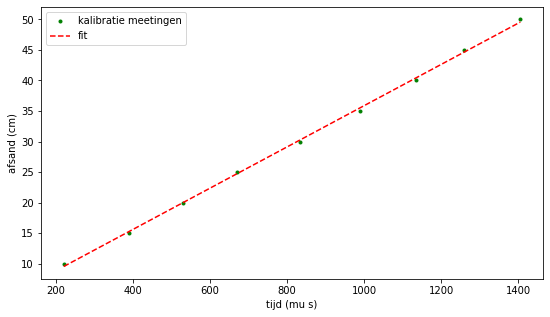

In [3]:
# verwerk hier jullie kalibratiemetingen
tijd = np.array([220,390,530,670,833,990,1134,1260,1405]) #mu s
afstand = np.array([10,15,20,25,30,35,40,45,50]) #cm

def fit_func(t,a,b):
    return a*t + b

var, cov = curve_fit(fit_func,tijd,afstand)

print(f'alpha={var[0]}, beta={var[1]}')

tijd_test = np.linspace(min(tijd),max(tijd),1000)
afstand_fit = fit_func(tijd_test,*var)
plt.figure(figsize=(9,5))
plt.plot(tijd,afstand,'g.',label='kalibratie meetingen')
plt.plot(tijd_test,afstand_fit,'r--',label='fit')
plt.xlabel('tijd (mu s)')
plt.ylabel('afsand (cm)')
plt.legend()
plt.plot()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  46.0
1   0  30   0  20  45.9
2  40   0  30   0  51.0
3  30   0  20   0  51.5


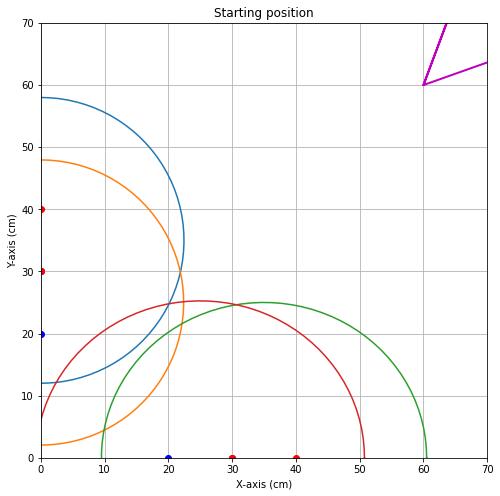


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=93.355


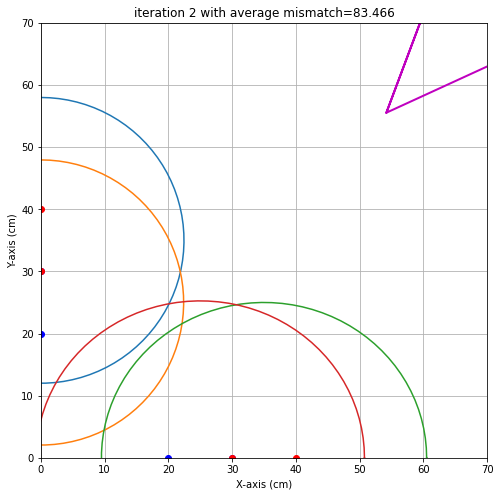

end iteration 2 with average mismatch=83.466


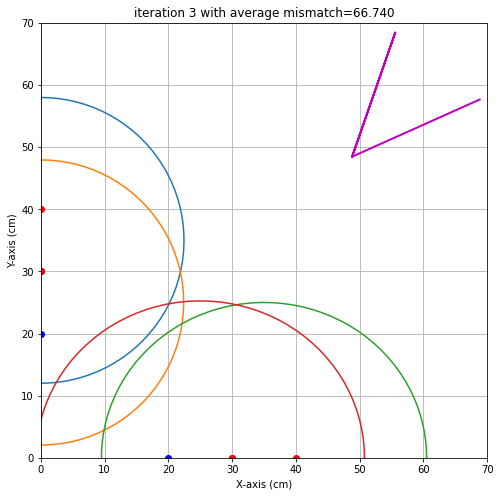

end iteration 3 with average mismatch=66.740


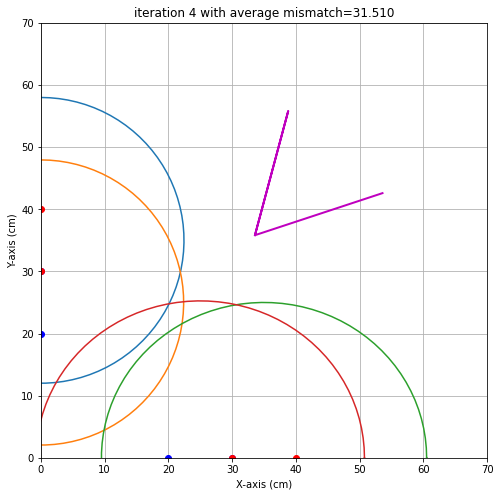

end iteration 4 with average mismatch=31.510


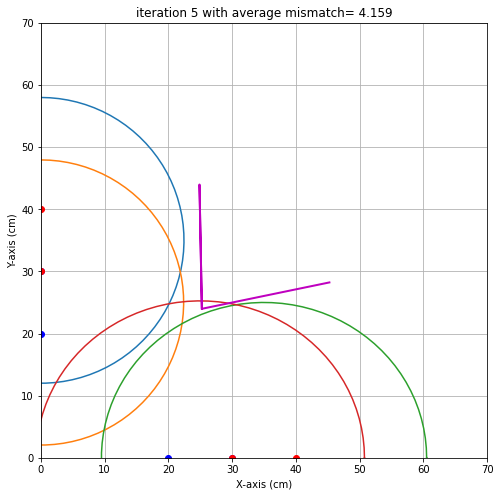

end iteration 5 with average mismatch= 4.159


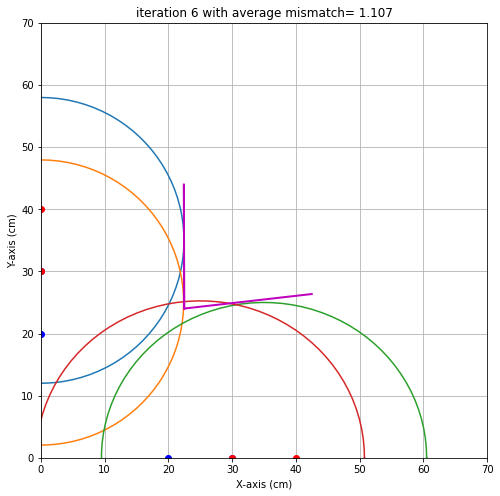

end iteration 6 with average mismatch= 1.107


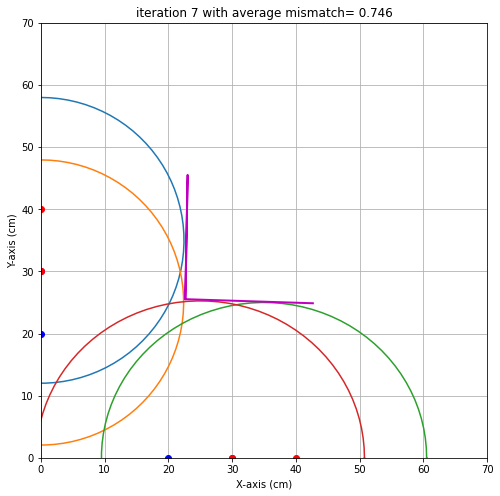

end iteration 7 with average mismatch= 0.746
end iteration 8 with average mismatch= 0.705


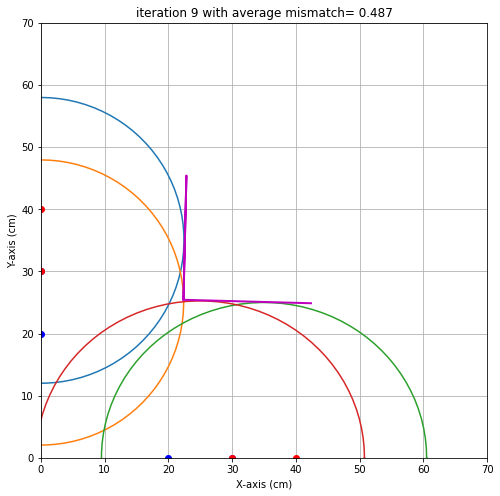

end iteration 9 with average mismatch= 0.487


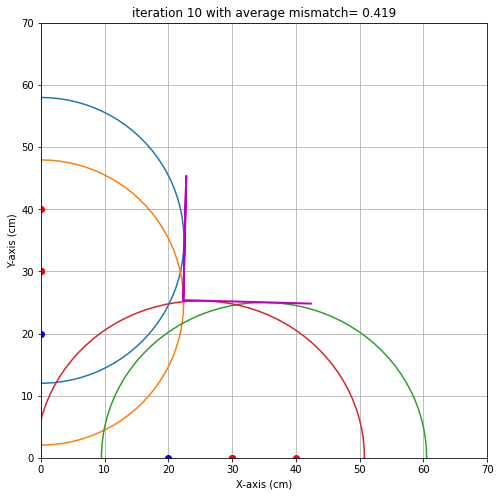

end iteration 10 with average mismatch= 0.419
end iteration 11 with average mismatch= 0.401
end iteration 12 with average mismatch= 0.397
end iteration 13 with average mismatch= 0.397
end iteration 14 with average mismatch= 0.397
end iteration 15 with average mismatch= 0.397
end iteration 16 with average mismatch= 0.397
end iteration 17 with average mismatch= 0.397
end iteration 18 with average mismatch= 0.397
end iteration 19 with average mismatch= 0.397
end iteration 20 with average mismatch= 0.397
end iteration 21 with average mismatch= 0.397
end iteration 22 with average mismatch= 0.397
end iteration 23 with average mismatch= 0.397
end iteration 24 with average mismatch= 0.397
end iteration 25 with average mismatch= 0.397
end iteration 26 with average mismatch= 0.397
end iteration 27 with average mismatch= 0.397
end iteration 28 with average mismatch= 0.397
end iteration 29 with average mismatch= 0.397
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

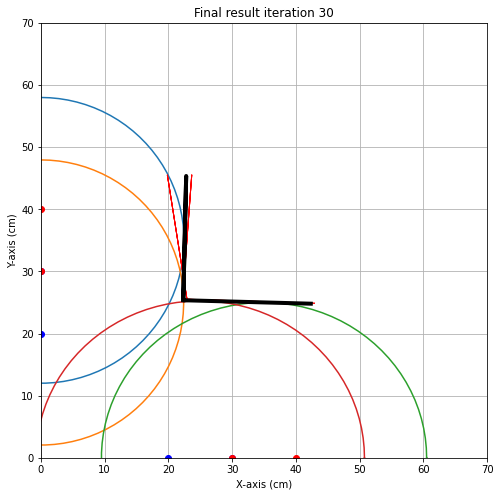

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,46.0],
    [0,30,0,20,45.9],
    #[0,10,0,20,190],
    [40,0,30,0,51.0],
    [30,0,20,0,51.5],
    #[10,0,20,0,-],
    #[10,0,0,10,163]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.3 cm met een standaardafwijking van 0.6 cm 
y0: 25.4 cm met een standaardafwijking van 0.2 cm 
alpha: -1.6 graden met een standaardafwijking van 0.7 graad 
beta: 1.3 graden met een standaardafwijking van 10.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Raphaelle]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algoritme_raphaelle.jpg" width="400">

#### algoritme [Erik]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algoritme_erik.jpg" width="400">

#### algoritme [Moene]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algoritme_moene.jpg" width="400">

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  46.0
1   0  30   0  20  45.9
2  40   0  30   0  51.0
3  30   0  20   0  51.5


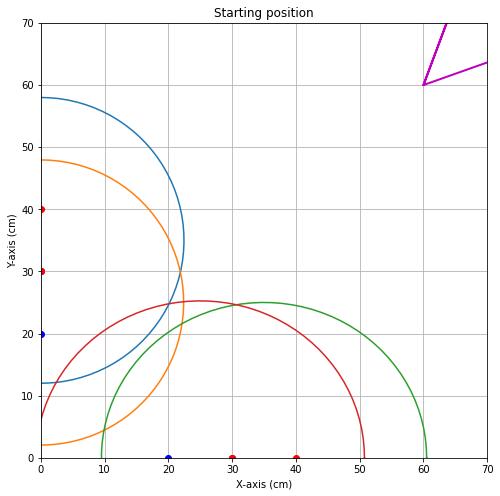


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=93.355


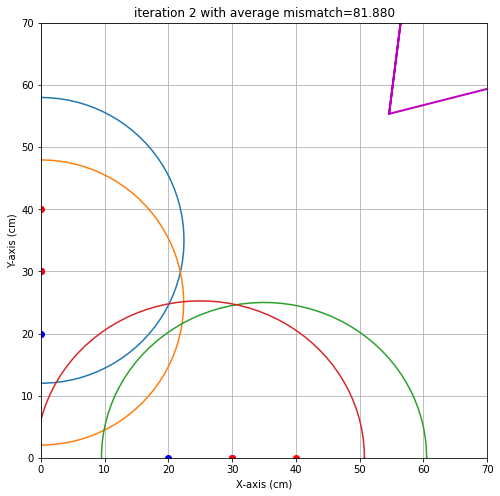

end iteration 2 with average mismatch=81.880


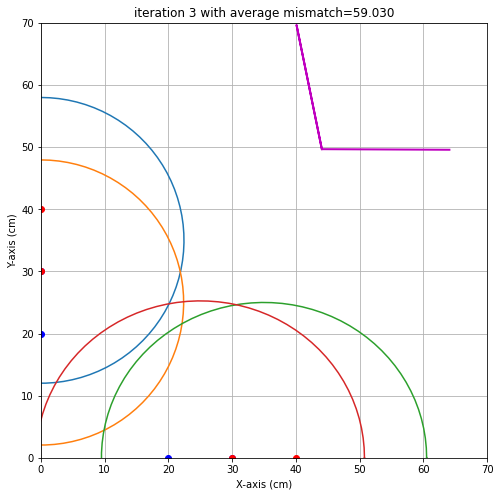

end iteration 3 with average mismatch=59.030


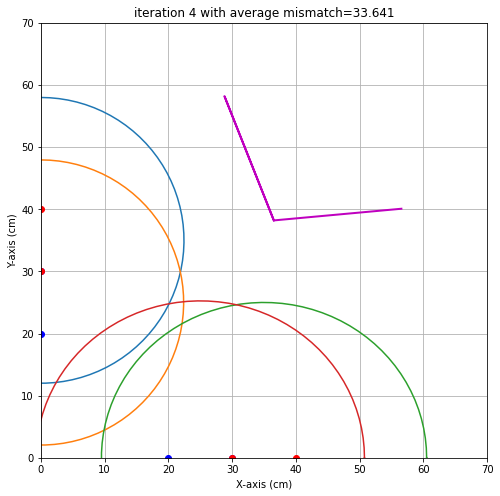

end iteration 4 with average mismatch=33.641


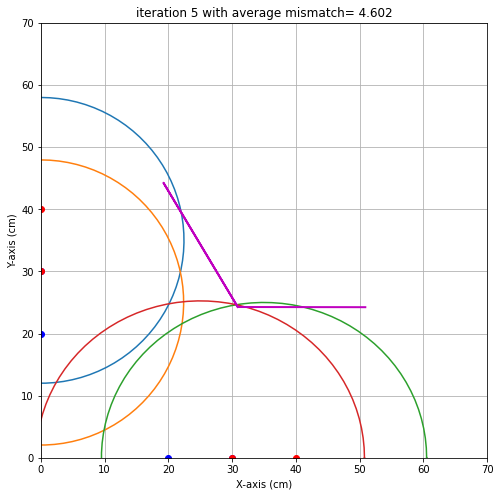

end iteration 5 with average mismatch= 4.602


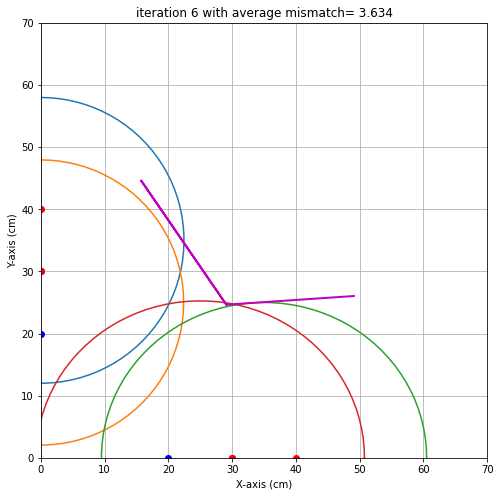

end iteration 6 with average mismatch= 3.634


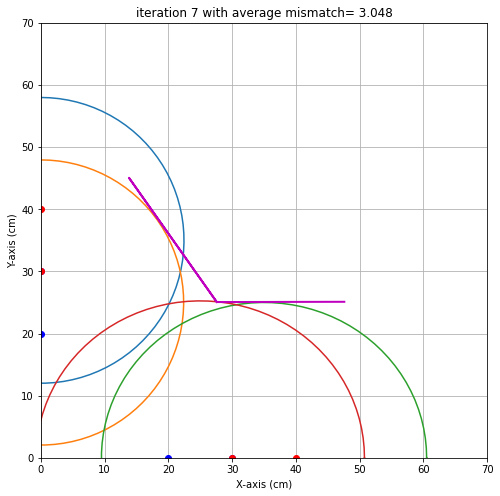

end iteration 7 with average mismatch= 3.048
end iteration 8 with average mismatch= 2.989
end iteration 9 with average mismatch= 2.953
end iteration 10 with average mismatch= 2.745


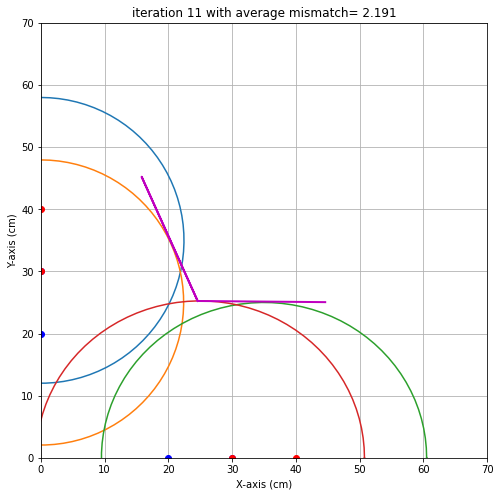

end iteration 11 with average mismatch= 2.191
end iteration 12 with average mismatch= 2.069
end iteration 13 with average mismatch= 1.880
end iteration 14 with average mismatch= 1.736


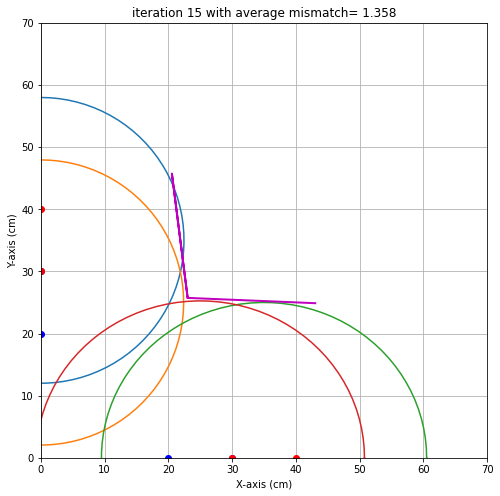

end iteration 15 with average mismatch= 1.358


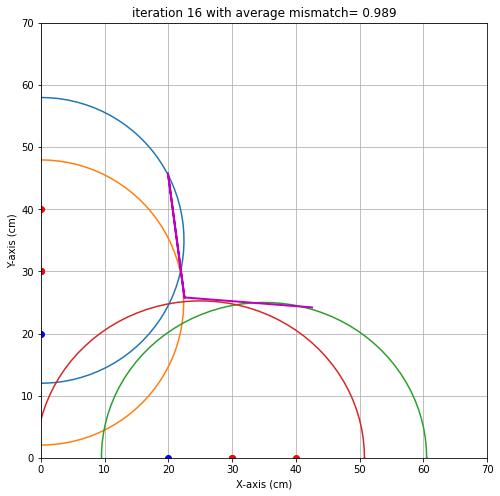

end iteration 16 with average mismatch= 0.989


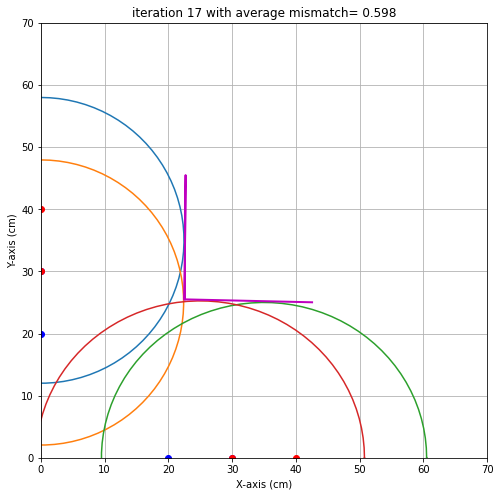

end iteration 17 with average mismatch= 0.598


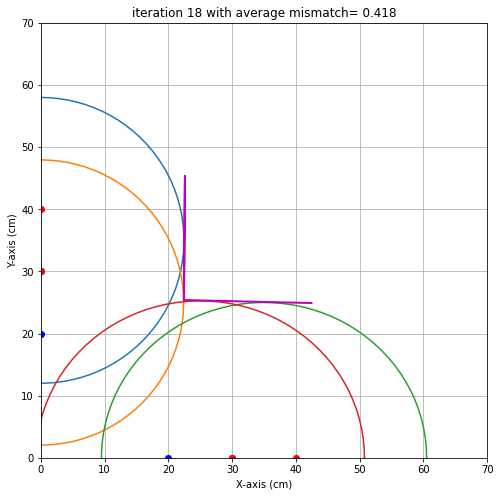

end iteration 18 with average mismatch= 0.418


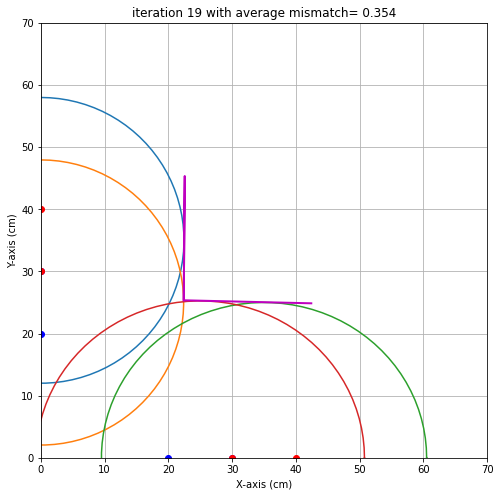

end iteration 19 with average mismatch= 0.354
end iteration 20 with average mismatch= 0.323
end iteration 21 with average mismatch= 0.322
end iteration 22 with average mismatch= 0.322
end iteration 23 with average mismatch= 0.322
end iteration 24 with average mismatch= 0.322
end iteration 25 with average mismatch= 0.322
end iteration 26 with average mismatch= 0.322
end iteration 27 with average mismatch= 0.322
end iteration 28 with average mismatch= 0.322
end iteration 29 with average mismatch= 0.322
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.322
###############################################################################
end of iteration  30
Best alpha=  -1.39 with uncertainty=   1.97
Best beta =   0.44 with uncertainty=   0.69
Best x0   =  22.39 with uncertainty=   0.15
Best y0   =  25.33 with uncertainty=   0.04
##############################################################

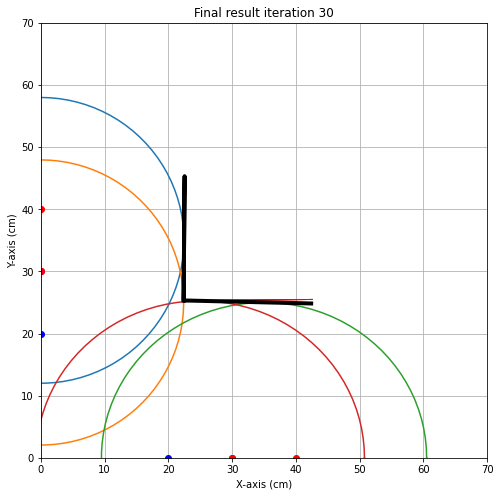

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

start_meetingen = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,46.0],
    [0,30,0,20,45.9],
    #[0,10,0,20,190],
    [40,0,30,0,51.0],
    [30,0,20,0,51.5],
    #[10,0,20,0,-],
    #[10,0,0,10,163]    
    ])

rough_location = imagingDEF.imagingDEF(start_meetingen)
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']


In [7]:

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')

range s: x=[22.39077175 46.3836868 ], y=[25.3273962  49.32668293]
range r: x=[21.15894125 45.18730196], y=[25.6726761 49.6755294]
s pos: (30.388410101456195,0), (38.38604845287516,0), (0,33.32715843986631), (0,41.3269206827737)
r pos: (29.16839481859205,0), (37.17784839165081,0), (0,33.673627198238556), (0,41.674578297276696)


## Opdracht 6: Test iteratie 0.

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  50   0  66.63
1  30   0  70   0  80.83
2  50   0  70   0  78.59
3   0  30   0  50  61.77
4   0  30   0  70  75.21


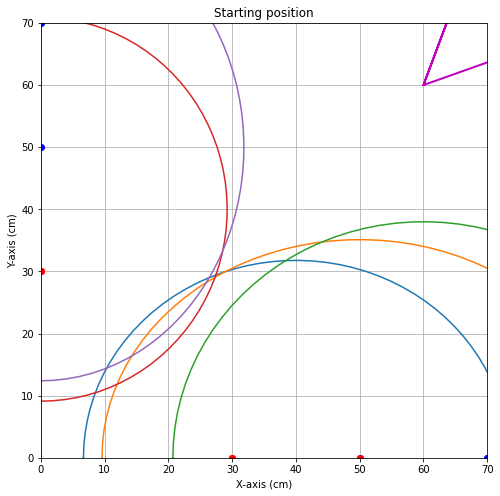


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.789


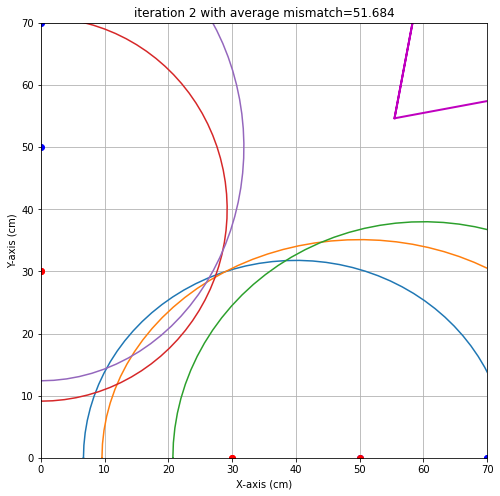

end iteration 2 with average mismatch=51.684


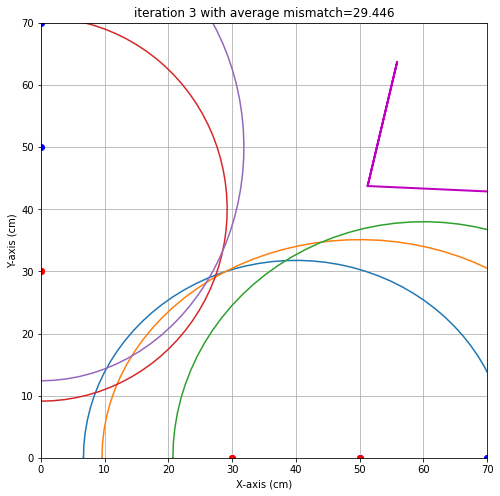

end iteration 3 with average mismatch=29.446


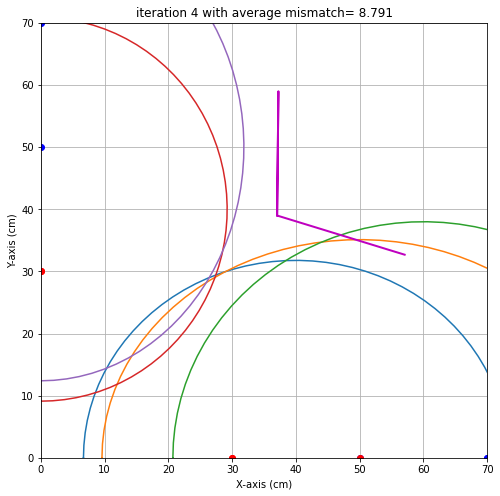

end iteration 4 with average mismatch= 8.791


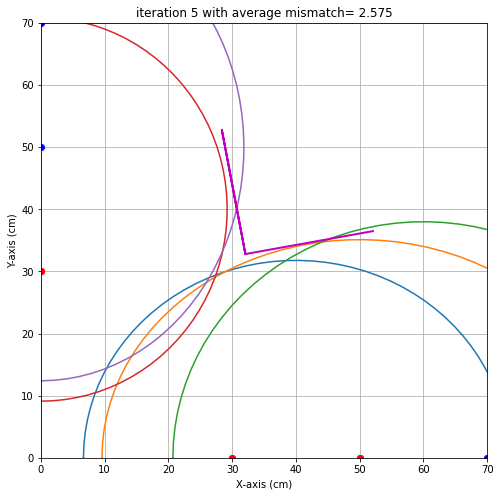

end iteration 5 with average mismatch= 2.575


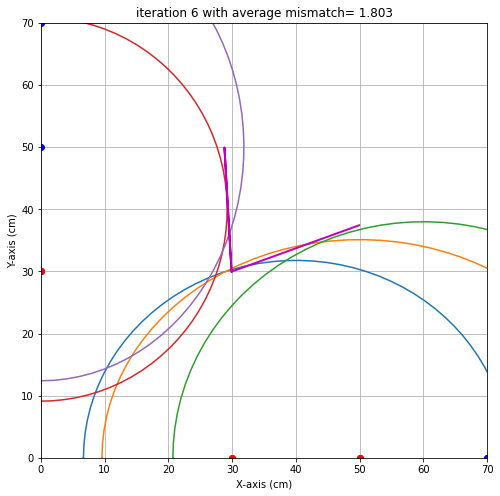

end iteration 6 with average mismatch= 1.803


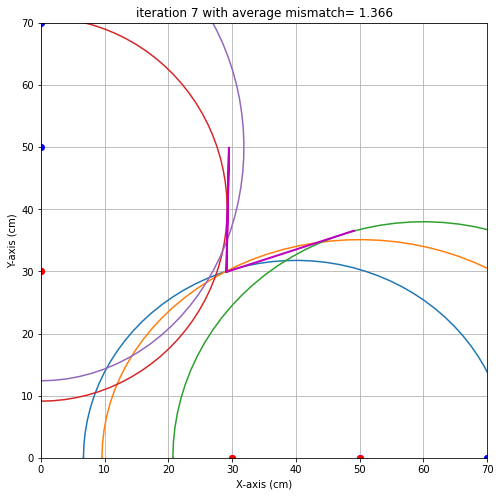

end iteration 7 with average mismatch= 1.366


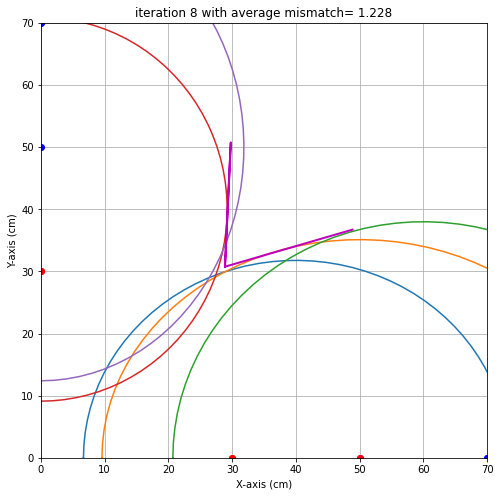

end iteration 8 with average mismatch= 1.228
end iteration 9 with average mismatch= 1.228
end iteration 10 with average mismatch= 1.228


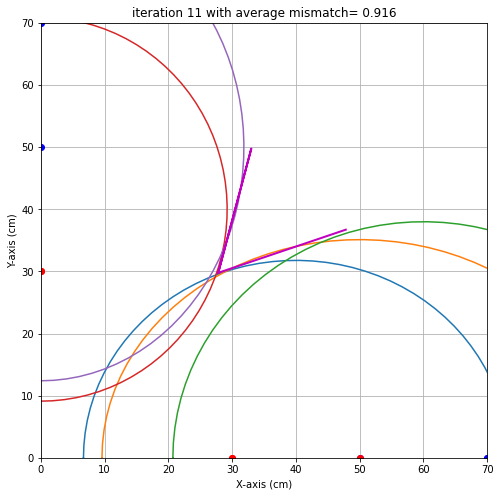

end iteration 11 with average mismatch= 0.916


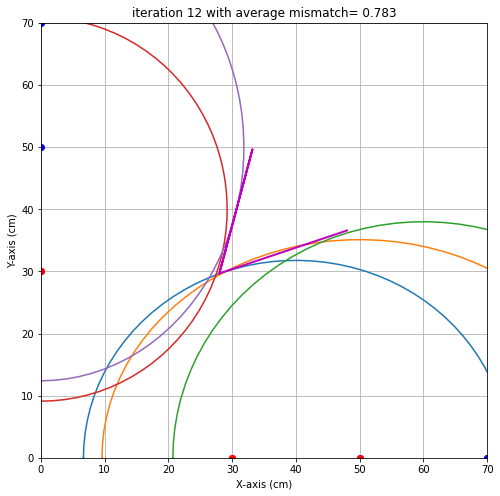

end iteration 12 with average mismatch= 0.783


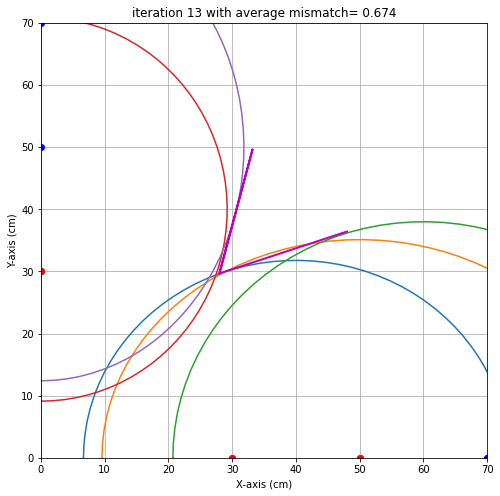

end iteration 13 with average mismatch= 0.674
end iteration 14 with average mismatch= 0.645
end iteration 15 with average mismatch= 0.593
end iteration 16 with average mismatch= 0.590
end iteration 17 with average mismatch= 0.590
end iteration 18 with average mismatch= 0.590
end iteration 19 with average mismatch= 0.590
end iteration 20 with average mismatch= 0.590
end iteration 21 with average mismatch= 0.590
end iteration 22 with average mismatch= 0.590
end iteration 23 with average mismatch= 0.590
end iteration 24 with average mismatch= 0.590
end iteration 25 with average mismatch= 0.590
end iteration 26 with average mismatch= 0.590
end iteration 27 with average mismatch= 0.590
end iteration 28 with average mismatch= 0.590
end iteration 29 with average mismatch= 0.590
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.590
###############################################################

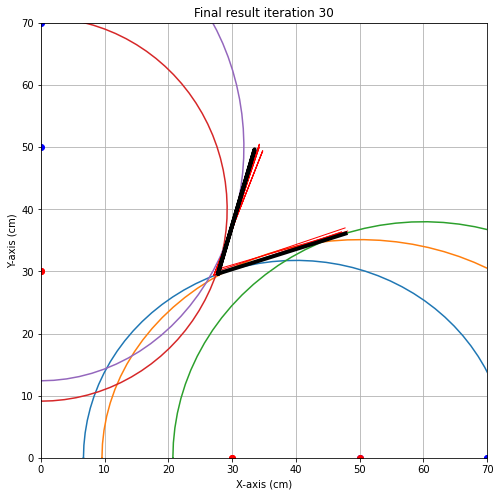

range s: x=[27.77979065 50.62077357], y=[29.64497684 52.71303535]
range r: x=[49.1272205  78.43303909], y=[47.02966318 75.17438472]
s pos: (35.393451620518775,0), (43.00711259544297,0), (0,37.33432967646117), (0,45.02368251100883)
r pos: (58.895826700381754,0), (68.66443289650758,0), (0,56.41123702421279), (0,65.79281087073875)


In [8]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':27,
           'y0':25,
           'alpha' : 10,
           'beta' : 0}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Moene' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,50,0,66.63],
    [30,0,70,0,80.83],
    [50,0,70,0,78.59],
    [0,30,0,50,61.77],
    [0,30,0,70,75.21],
    #[0,50,0,70,-]
    ]),
       'Erik' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,-],
    [35,0,55,0,68.81],
    [50,0,70,0,77.91],
    [0,20,0,40,61.53],
    [0,35,0,55,61.90],
    #[0,45,0,70,-],
    [70,0,45,0,78.21],
    [50,0,65,0,76.51],
    [65,0,35,0,78.85],
    [0,35,0,45,57.12],
    #[0,20,0,50,-],
    [0,45,0,30,59.61]
    ])
      }

rough_location = imagingDEF.imagingDEF(data['Moene'])
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')

In [9]:
data ={'Moene' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,50,0,66.63],
    [30,0,70,0,80.83],
    [50,0,70,0,78.59],
    [0,30,0,50,61.77],
    [0,30,0,70,75.21],
    #[0,50,0,70,-],
    [35,0,60,0,72.99],
    [43,0,70,0,77.77],
    [0,37,0,58,61.43]
    #[0,45,0,67,-]
    ]),
       'Erik' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,-],
    [35,0,55,0,68.81],
    [50,0,70,0,77.91],
    [0,20,0,40,61.53],
    [0,35,0,55,61.90],
    #[0,45,0,70,-],
    [70,0,45,0,78.21],
    [50,0,65,0,76.51],
    [65,0,35,0,78.85],
    [0,35,0,45,57.12],
    #[0,20,0,50,-],
    [0,45,0,30,59.61]
    ])
      }

## Opdracht 7: Evaluatie.

Moene
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  50   0  66.63
1  30   0  70   0  80.83
2  50   0  70   0  78.59
3   0  30   0  50  61.77
4   0  30   0  70  75.21
5  35   0  60   0  72.99
6  43   0  70   0  77.77
7   0  37   0  58  61.43


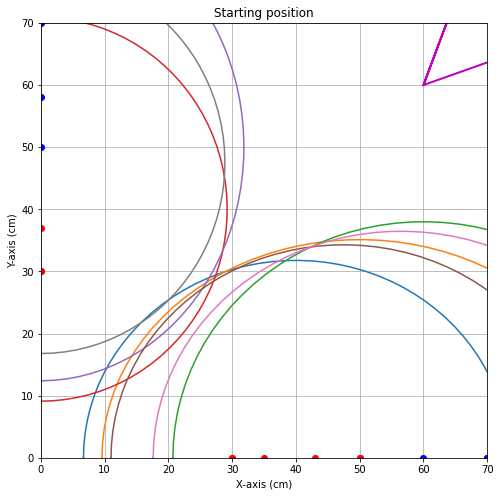


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.658


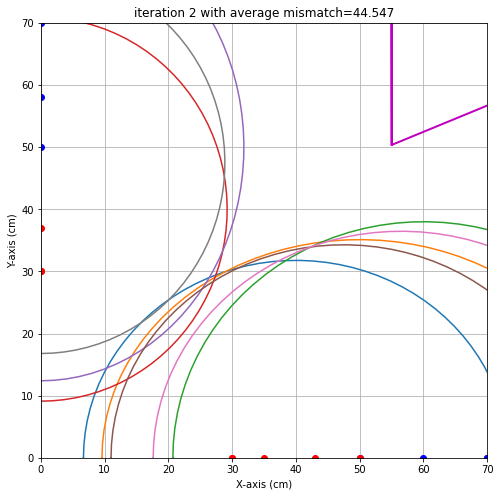

end iteration 2 with average mismatch=44.547


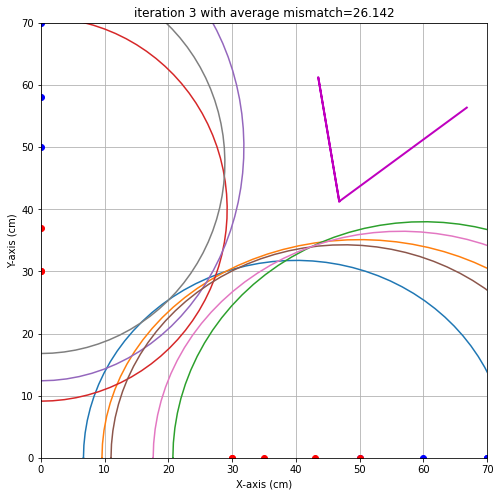

end iteration 3 with average mismatch=26.142


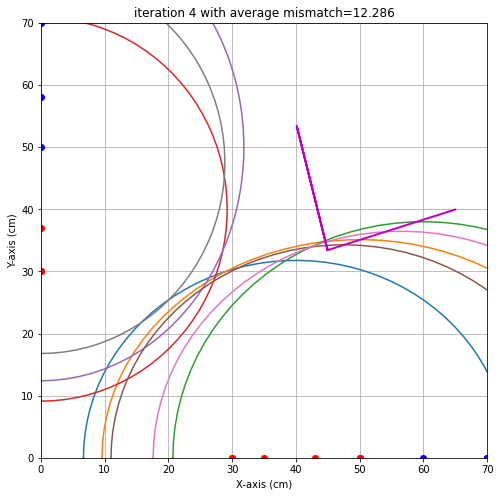

end iteration 4 with average mismatch=12.286


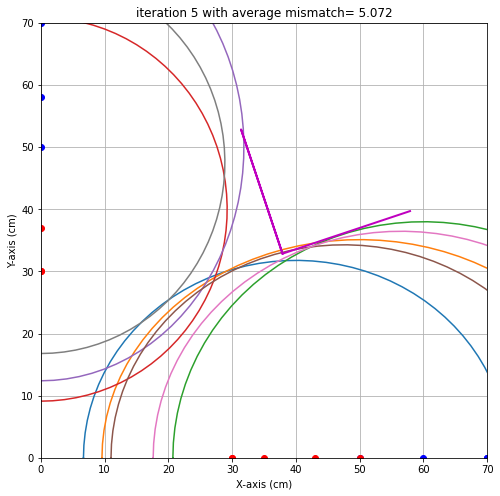

end iteration 5 with average mismatch= 5.072


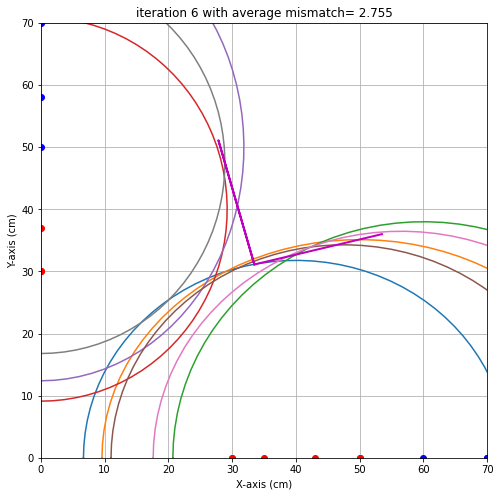

end iteration 6 with average mismatch= 2.755


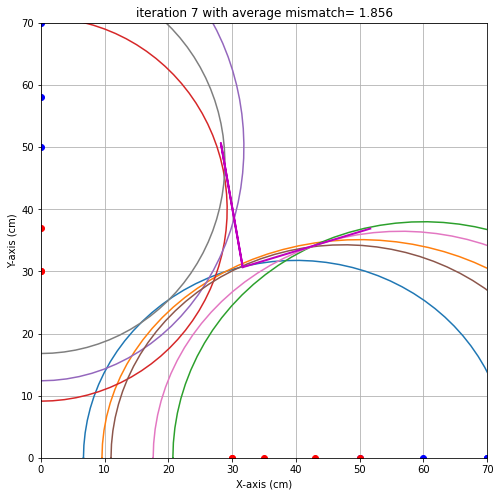

end iteration 7 with average mismatch= 1.856


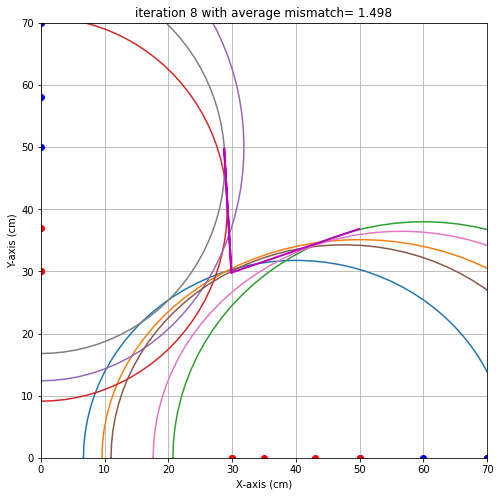

end iteration 8 with average mismatch= 1.498


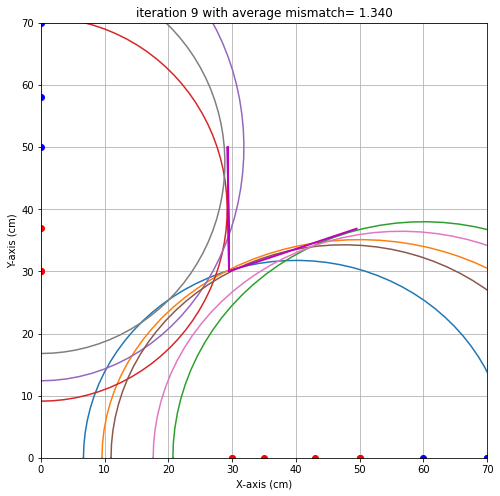

end iteration 9 with average mismatch= 1.340


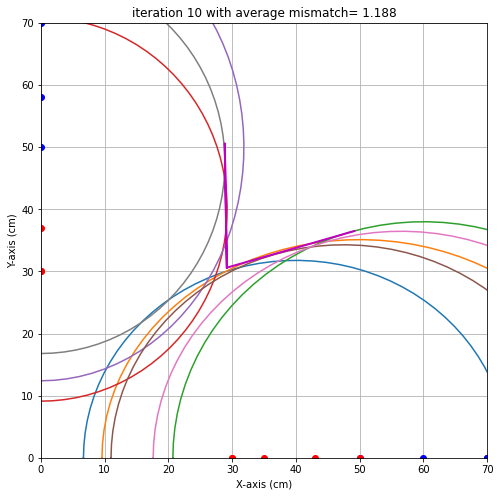

end iteration 10 with average mismatch= 1.188
end iteration 11 with average mismatch= 1.167
end iteration 12 with average mismatch= 1.106
end iteration 13 with average mismatch= 1.050
end iteration 14 with average mismatch= 1.041
end iteration 15 with average mismatch= 1.038
end iteration 16 with average mismatch= 1.038
end iteration 17 with average mismatch= 1.038
end iteration 18 with average mismatch= 1.038
end iteration 19 with average mismatch= 1.038
end iteration 20 with average mismatch= 1.038
end iteration 21 with average mismatch= 1.038
end iteration 22 with average mismatch= 1.038
end iteration 23 with average mismatch= 1.038
end iteration 24 with average mismatch= 1.038
end iteration 25 with average mismatch= 1.038
end iteration 26 with average mismatch= 1.038
end iteration 27 with average mismatch= 1.038
end iteration 28 with average mismatch= 1.038
end iteration 29 with average mismatch= 1.038
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

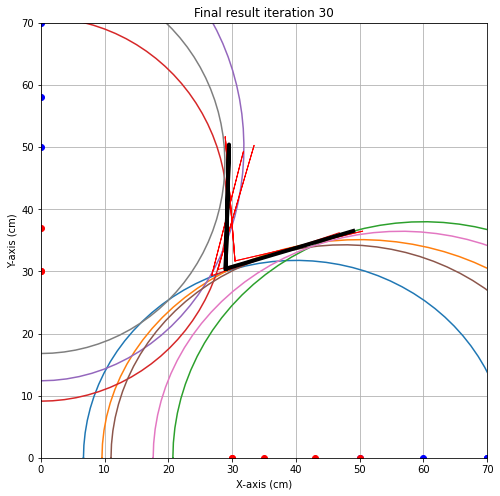

{'alpha': 16.922338040342325, 'alpha_eps': 3.470299157862346, 'beta': 1.5060564789767472, 'beta_eps': 14.425071507007145, 'x0': 28.981096368532977, 'x0_eps': 2.185082342260717, 'y0': 30.42382127056168, 'y0_eps': 1.2644307309329008}
Erik
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  35   0  55   0  68.81
1  50   0  70   0  77.91
2   0  20   0  40  61.53
3   0  35   0  55  61.90
4  70   0  45   0  78.21
5  50   0  65   0  76.51
6  65   0  35   0  78.85
7   0  35   0  45  57.12
8   0  45   0  30  59.61


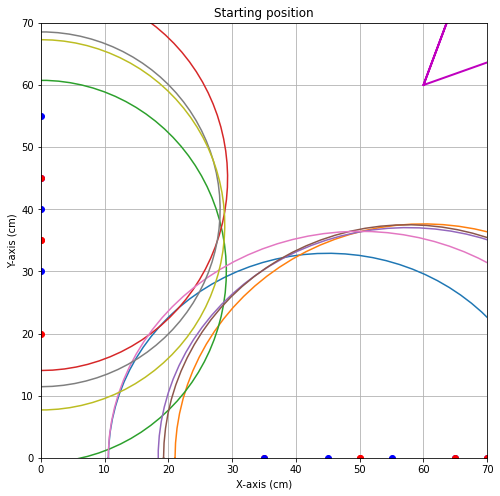


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.820


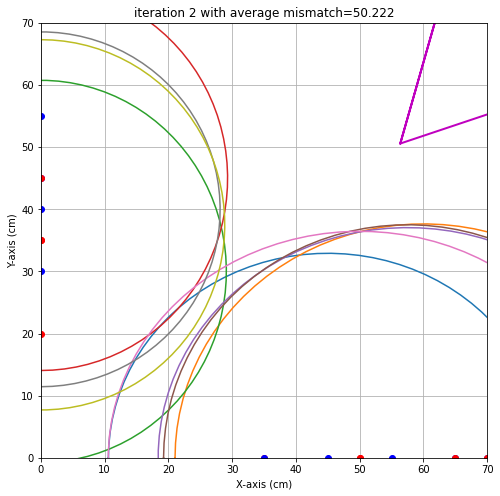

end iteration 2 with average mismatch=50.222


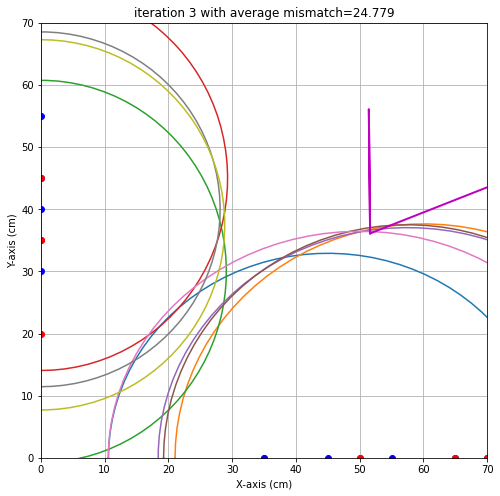

end iteration 3 with average mismatch=24.779


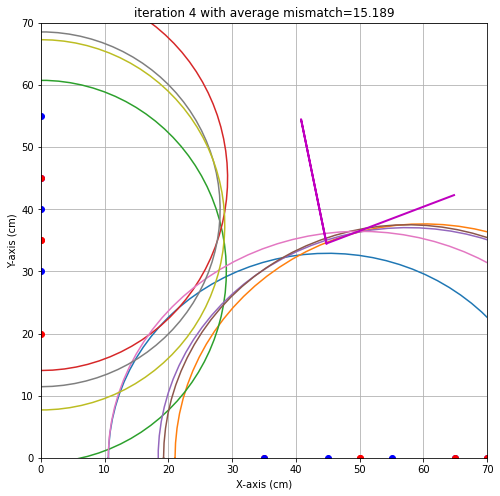

end iteration 4 with average mismatch=15.189


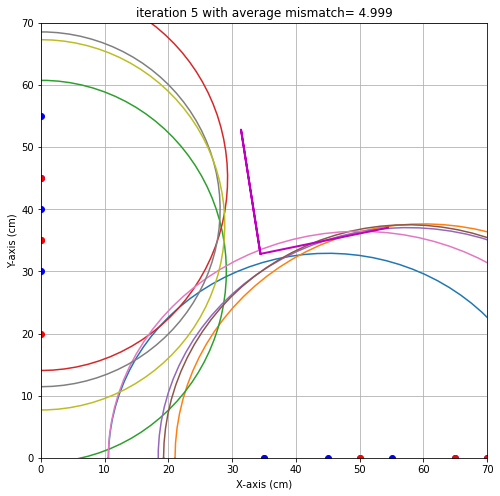

end iteration 5 with average mismatch= 4.999


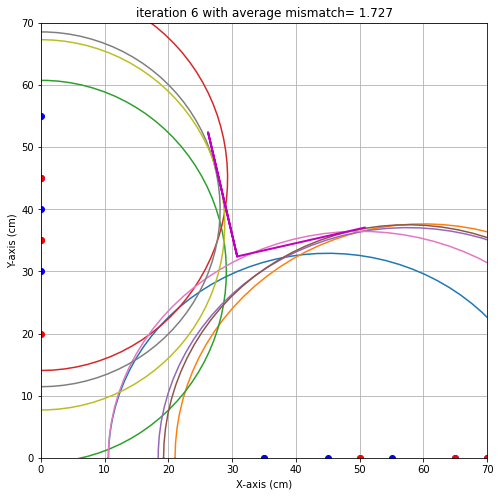

end iteration 6 with average mismatch= 1.727


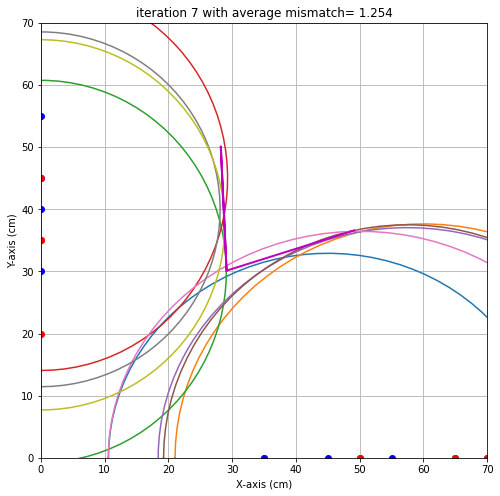

end iteration 7 with average mismatch= 1.254
end iteration 8 with average mismatch= 1.188
end iteration 9 with average mismatch= 1.171
end iteration 10 with average mismatch= 1.170
end iteration 11 with average mismatch= 1.169
end iteration 12 with average mismatch= 1.169
end iteration 13 with average mismatch= 1.165
end iteration 14 with average mismatch= 1.160
end iteration 15 with average mismatch= 1.119
end iteration 16 with average mismatch= 1.106
end iteration 17 with average mismatch= 1.105
end iteration 18 with average mismatch= 1.105
end iteration 19 with average mismatch= 1.083
end iteration 20 with average mismatch= 1.068
end iteration 21 with average mismatch= 1.066
end iteration 22 with average mismatch= 1.066
end iteration 23 with average mismatch= 1.065
end iteration 24 with average mismatch= 1.065
end iteration 25 with average mismatch= 1.065
end iteration 26 with average mismatch= 1.065
end iteration 27 with average mismatch= 1.065
end iteration 28 with average mismatc

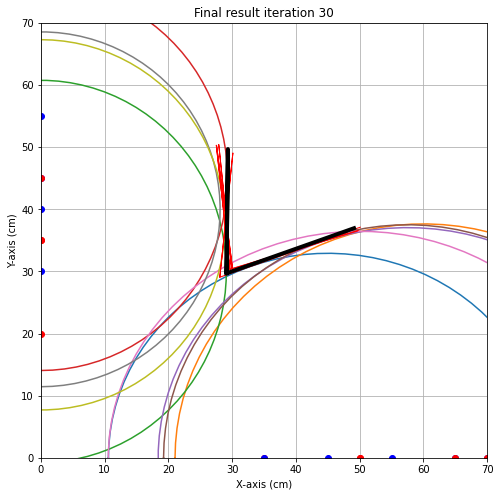

{'alpha': 19.951762824251897, 'alpha_eps': 2.754528713862996, 'beta': 0.6440472208077069, 'beta_eps': 7.855235414188737, 'x0': 29.113193295560723, 'x0_eps': 1.0498324021443253, 'y0': 29.69303142646808, 'y0_eps': 0.7422697403073428}
Raphaelle


KeyError: 'Raphaelle'

In [10]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [11]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Moene 
x0 target is : 27.0. Gevonden waarde: 29.0 cm met een standaardafwijking van 2.2 cm 
y0 target is : 25.0. Gevonden waarde: 30.4 cm met een standaardafwijking van 1.3 cm 
alpha target is : 10.0. Gevonden waarde: 16.9 graden met een standaardafwijking van 3.5 graad 
beta target is : 0.0. Gevonden waarde: 1.5 graden met een standaardafwijking van 14.4 graad 

Erik 
x0 target is : 27.0. Gevonden waarde: 29.1 cm met een standaardafwijking van 1.0 cm 
y0 target is : 25.0. Gevonden waarde: 29.7 cm met een standaardafwijking van 0.7 cm 
alpha target is : 10.0. Gevonden waarde: 20.0 graden met een standaardafwijking van 2.8 graad 
beta target is : 0.0. Gevonden waarde: 0.6 graden met een standaardafwijking van 7.9 graad 



KeyError: 'Raphaelle'

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_iteratie.jpg)


In [12]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  47.88
1  40   0  55   0  51.26
2   0  30   0  45  58.07
3   0  40   0  55  62.91


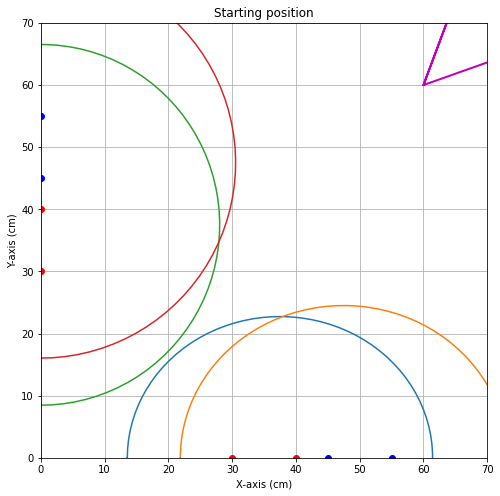


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=77.747


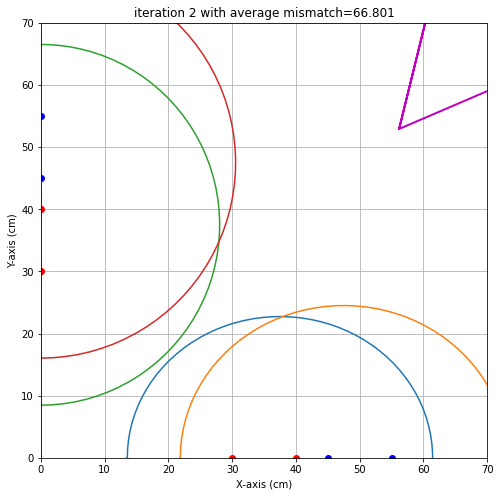

end iteration 2 with average mismatch=66.801


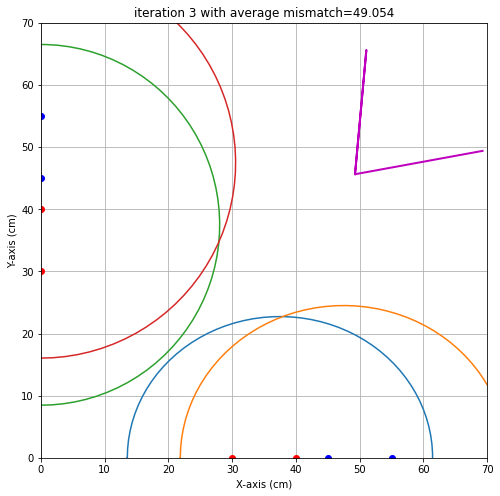

end iteration 3 with average mismatch=49.054


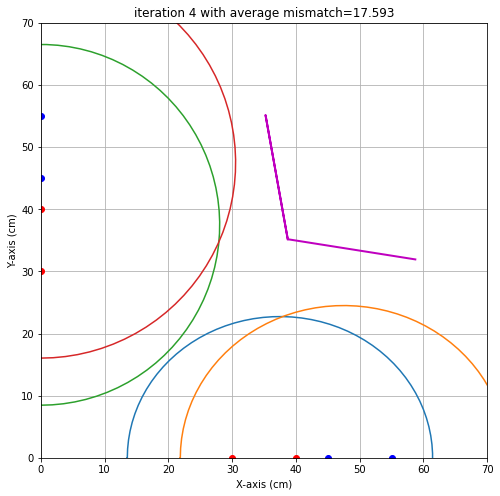

end iteration 4 with average mismatch=17.593


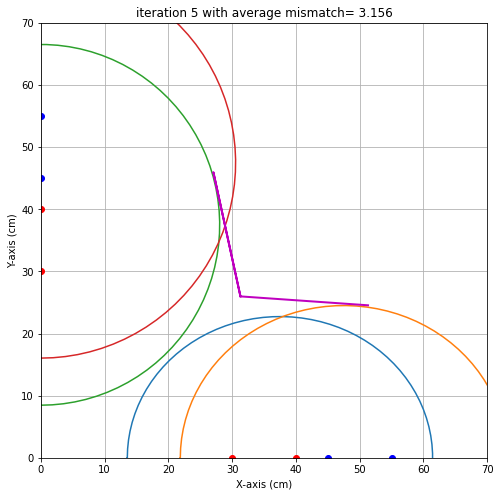

end iteration 5 with average mismatch= 3.156
end iteration 6 with average mismatch= 2.953
end iteration 7 with average mismatch= 2.791


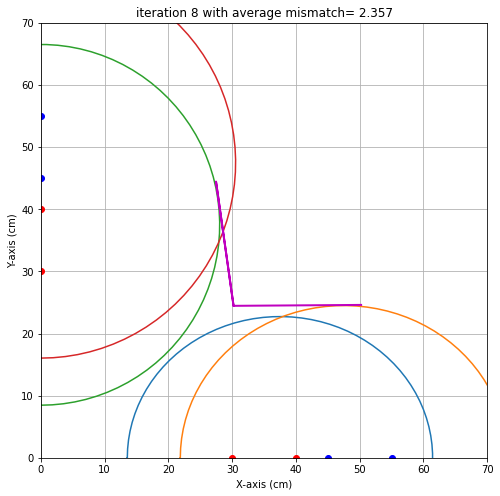

end iteration 8 with average mismatch= 2.357


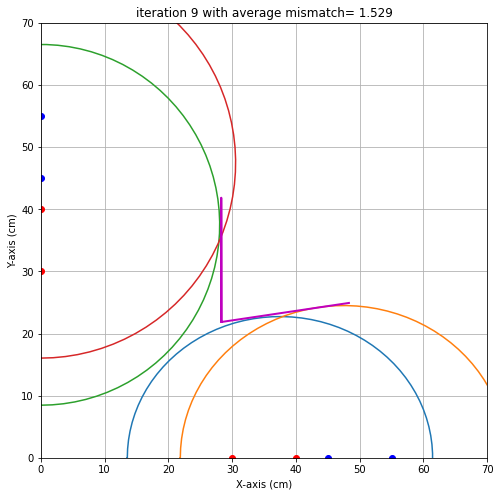

end iteration 9 with average mismatch= 1.529


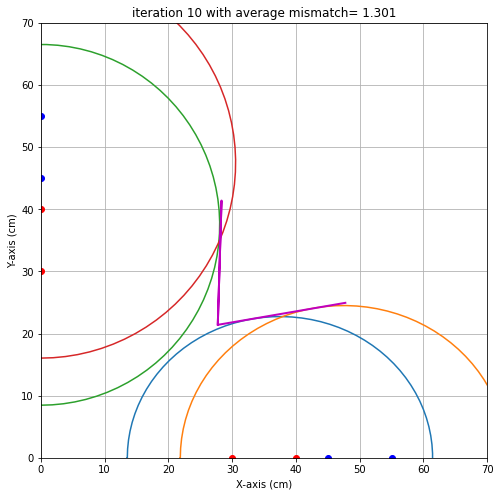

end iteration 10 with average mismatch= 1.301
end iteration 11 with average mismatch= 1.266
end iteration 12 with average mismatch= 1.227
end iteration 13 with average mismatch= 1.208
end iteration 14 with average mismatch= 1.206
end iteration 15 with average mismatch= 1.206
end iteration 16 with average mismatch= 1.206
end iteration 17 with average mismatch= 1.206
end iteration 18 with average mismatch= 1.206
end iteration 19 with average mismatch= 1.206
end iteration 20 with average mismatch= 1.105


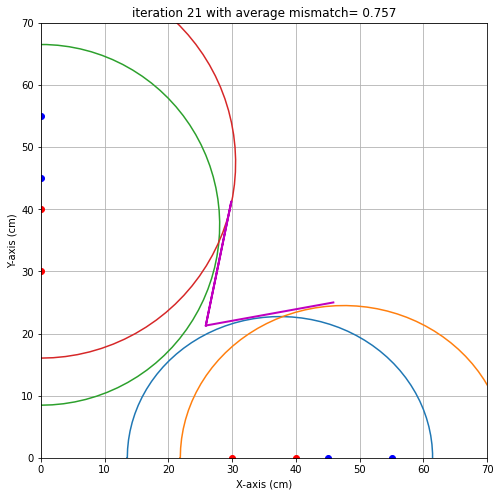

end iteration 21 with average mismatch= 0.757


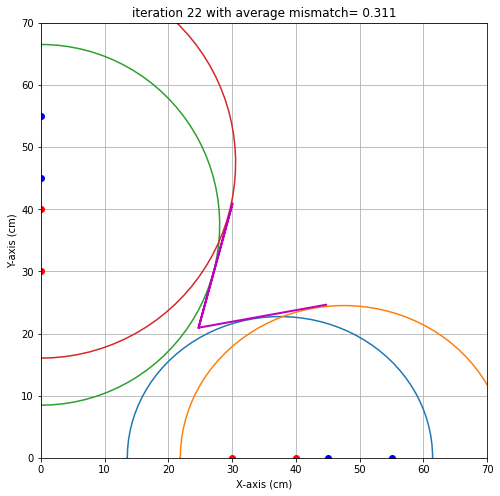

end iteration 22 with average mismatch= 0.311


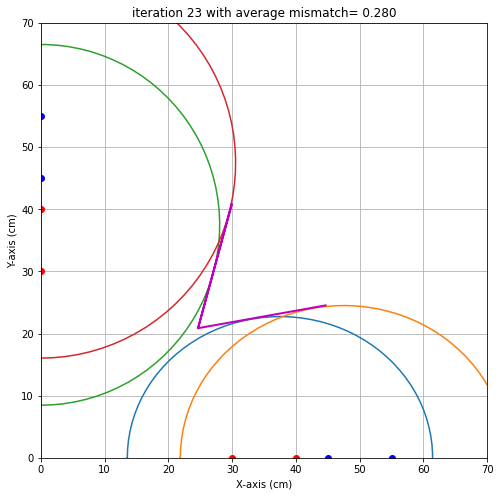

end iteration 23 with average mismatch= 0.280


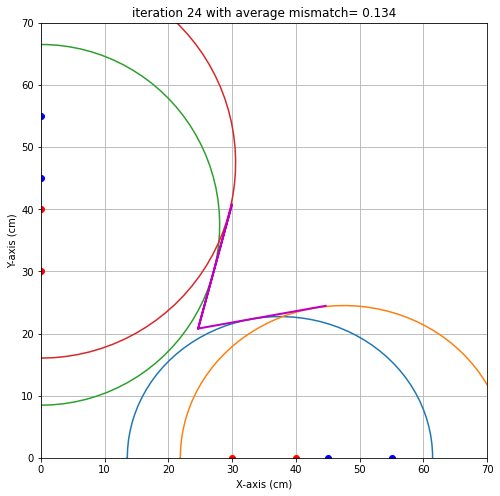

end iteration 24 with average mismatch= 0.134
end iteration 25 with average mismatch= 0.133
end iteration 26 with average mismatch= 0.133
end iteration 27 with average mismatch= 0.132
end iteration 28 with average mismatch= 0.132
end iteration 29 with average mismatch= 0.132
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.132
###############################################################################
end of iteration  30
Best alpha=  10.37 with uncertainty=   0.00
Best beta =  14.85 with uncertainty=   0.00
Best x0   =  24.66 with uncertainty=   0.00
Best y0   =  20.80 with uncertainty=   0.00
###############################################################################
no uncertainty found, please run again


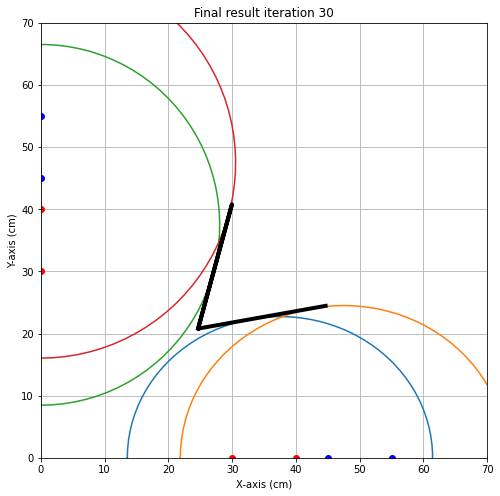

range s: x=[24.66355865 48.27144633], y=[20.79791071 43.99603861]
range r: x=[32.54005356 58.17633492], y=[34.86867407 62.37842951]
s pos: (32.53285454257103,0), (40.40215043876664,0), (0,28.530620010732992), (0,36.263329312691674)
r pos: (41.085480679938954,0), (49.63090779996642,0), (0,44.0385925533581), (0,53.208511032788614)


In [13]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':31,
                    'y0':33,
                    'alpha' : 9,
                    'beta' : -11},
           'locatie 2':{'x0':23,
                    'y0': 21,
                    'alpha' : -3,
                    'beta' : 11}
           }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,76.53],
    [50,0,65,0,81.25],
    [40,0,55,0,77.01],
    [0,30,0,45,66.18],
    [0,40,0,55,63.01]
    #[0,50,0,65,-]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,47.88],
    #[50,0,65,0,-],
    [40,0,55,0,51.26],
    [0,30,0,45,58.07],
    [0,40,0,55,62.91]
    #[0,50,0,65,-]
    ])
      }


rough_location = imagingDEF.imagingDEF(data['locatie 2'])
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')                        

In [14]:
data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,76.53],
    [50,0,65,0,81.25],
    [40,0,55,0,77.01],
    [0,30,0,45,66.18],
    [0,40,0,55,63.01],
    #[0,50,0,65]
    [41,0,56,0,77.67],
    [49,0,65,0,81.35],
    [0,44,0,33,65.04],
    [0,52,0,41,61.60]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,47.88],
    #[50,0,65,0,-],
    [40,0,55,0,51.26],
    [0,30,0,45,58.07],
    [0,40,0,55,62.91],
    #[0,50,0,65,-]
    [33,0,41,0,45.29],
    [41,0,49,0,45.52],
    [0,29,0,43,56.51],
    [0,37,0,52,60.90]
    ])
      }

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  76.53
1  50   0  65   0  81.25
2  40   0  55   0  77.01
3   0  30   0  45  66.18
4   0  40   0  55  63.01
5  41   0  56   0  77.67
6  49   0  65   0  81.35
7   0  44   0  33  65.04
8   0  52   0  41  61.60


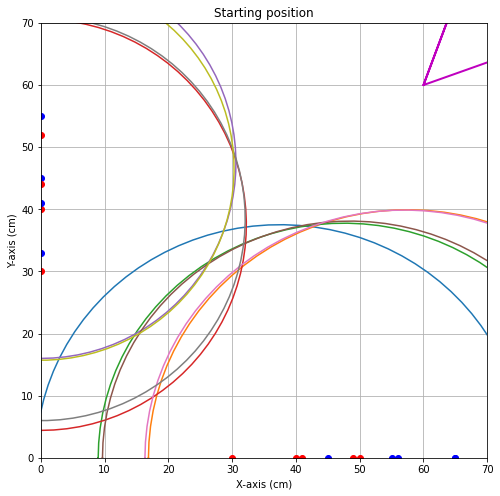


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.259


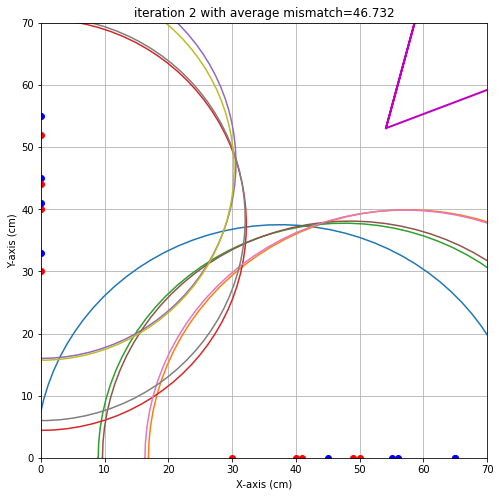

end iteration 2 with average mismatch=46.732


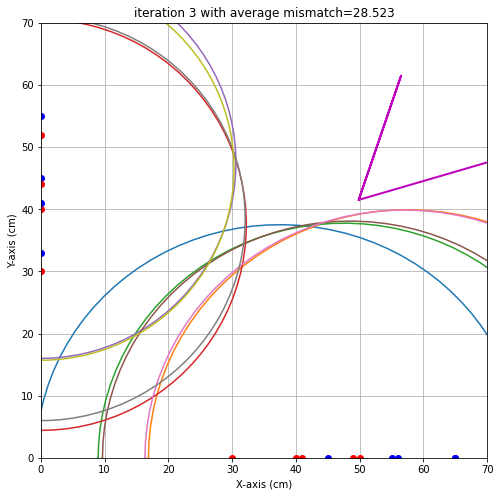

end iteration 3 with average mismatch=28.523


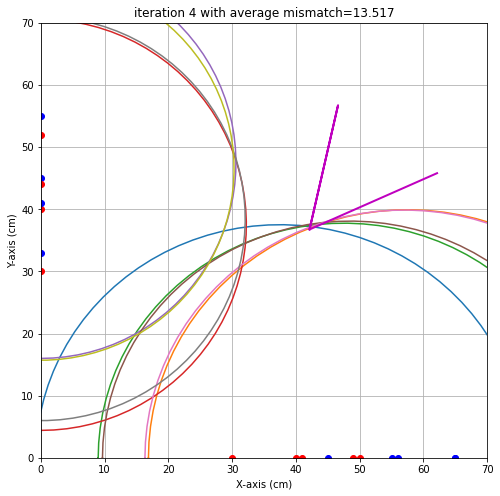

end iteration 4 with average mismatch=13.517


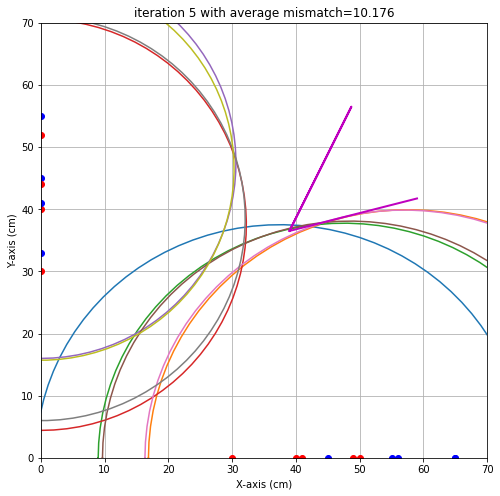

end iteration 5 with average mismatch=10.176


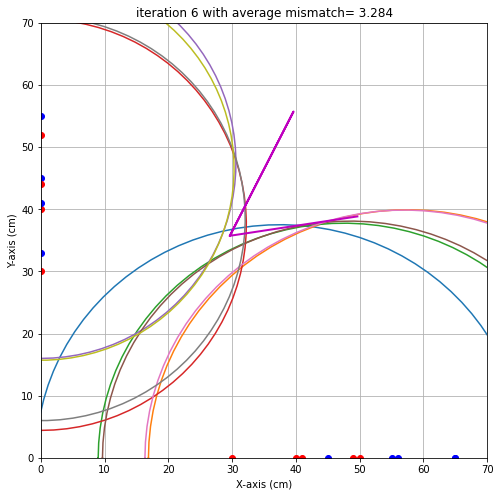

end iteration 6 with average mismatch= 3.284


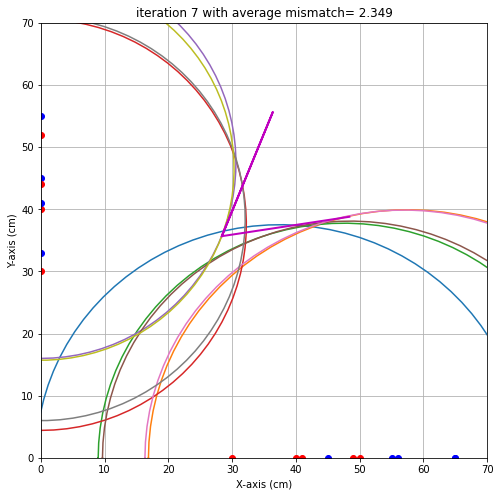

end iteration 7 with average mismatch= 2.349


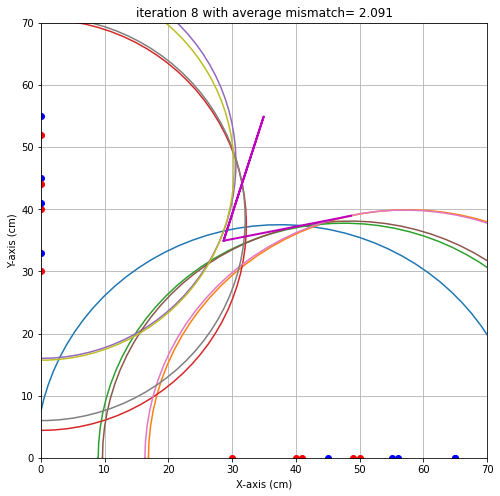

end iteration 8 with average mismatch= 2.091
end iteration 9 with average mismatch= 1.916
end iteration 10 with average mismatch= 1.916
end iteration 11 with average mismatch= 1.912
end iteration 12 with average mismatch= 1.912
end iteration 13 with average mismatch= 1.912
end iteration 14 with average mismatch= 1.826
end iteration 15 with average mismatch= 1.825
end iteration 16 with average mismatch= 1.820
end iteration 17 with average mismatch= 1.814
end iteration 18 with average mismatch= 1.814
end iteration 19 with average mismatch= 1.745


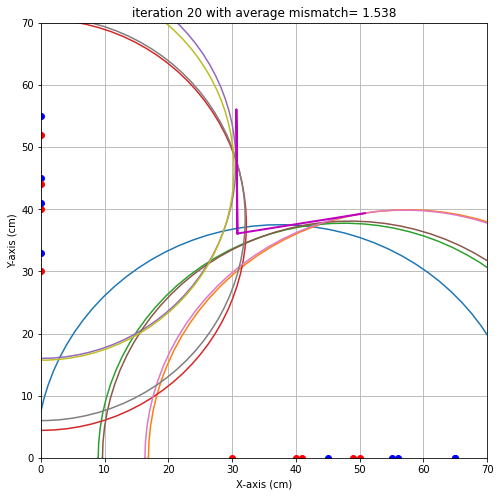

end iteration 20 with average mismatch= 1.538


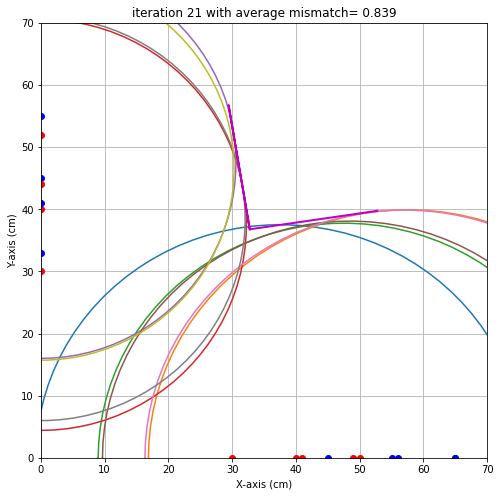

end iteration 21 with average mismatch= 0.839
end iteration 22 with average mismatch= 0.776
end iteration 23 with average mismatch= 0.740
end iteration 24 with average mismatch= 0.704
end iteration 25 with average mismatch= 0.704
end iteration 26 with average mismatch= 0.704
end iteration 27 with average mismatch= 0.704
end iteration 28 with average mismatch= 0.704
end iteration 29 with average mismatch= 0.704
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.704
###############################################################################
end of iteration  30
Best alpha=   8.38 with uncertainty=   5.21
Best beta =  -9.39 with uncertainty=   4.10
Best x0   =  32.80 with uncertainty=   1.05
Best y0   =  36.72 with uncertainty=   1.10
###############################################################################


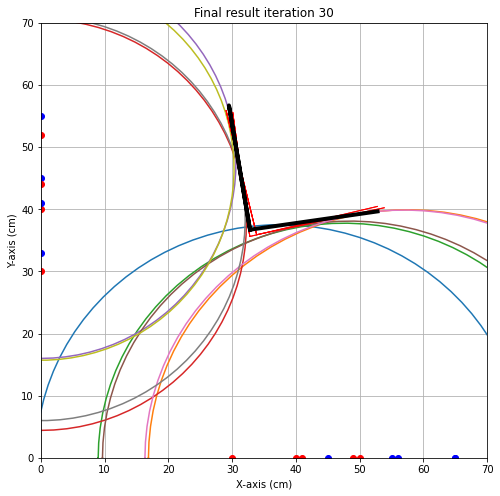

{'alpha': 8.375105510368119, 'alpha_eps': 5.211339919760341, 'beta': -9.386247805011548, 'beta_eps': 4.103997196692218, 'x0': 32.80162400252411, 'x0_eps': 1.0450024185113662, 'y0': 36.721013150122666, 'y0_eps': 1.0957793524320678}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  47.88
1  40   0  55   0  51.26
2   0  30   0  45  58.07
3   0  40   0  55  62.91
4  33   0  41   0  45.29
5  41   0  49   0  45.52
6   0  29   0  43  56.51
7   0  37   0  52  60.90


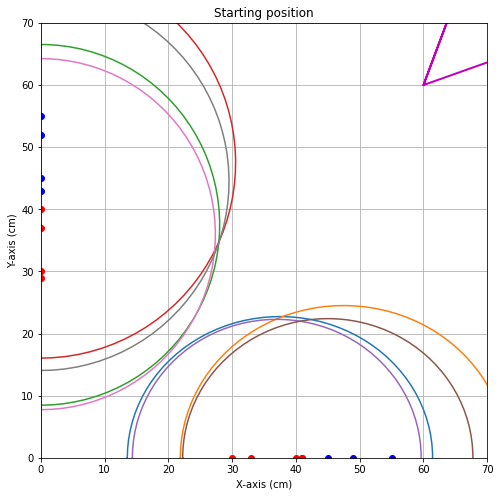


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.639


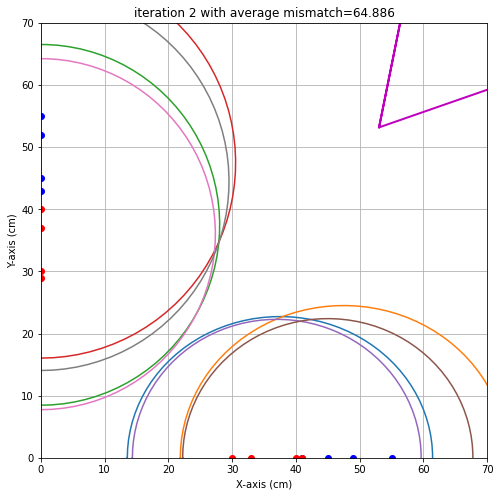

end iteration 2 with average mismatch=64.886


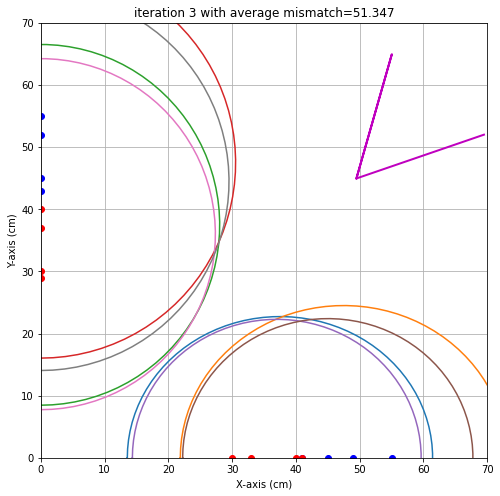

end iteration 3 with average mismatch=51.347


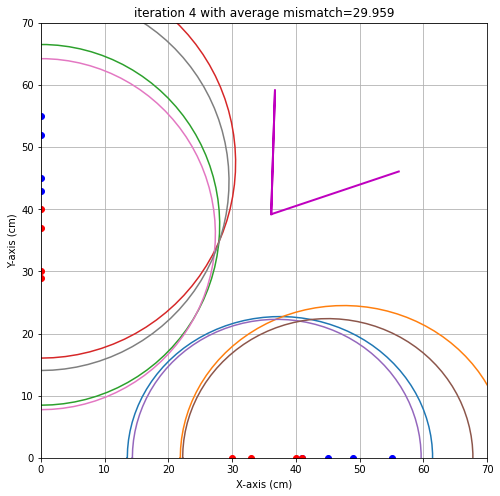

end iteration 4 with average mismatch=29.959


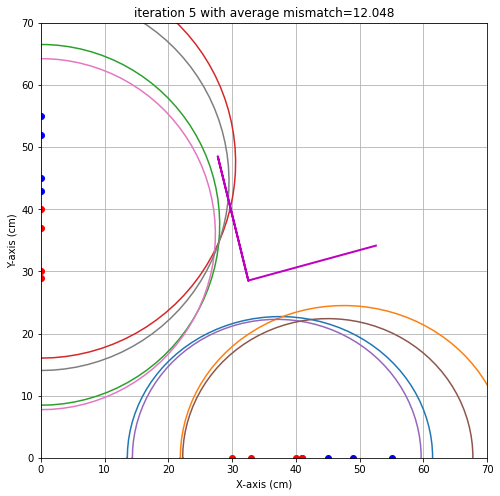

end iteration 5 with average mismatch=12.048


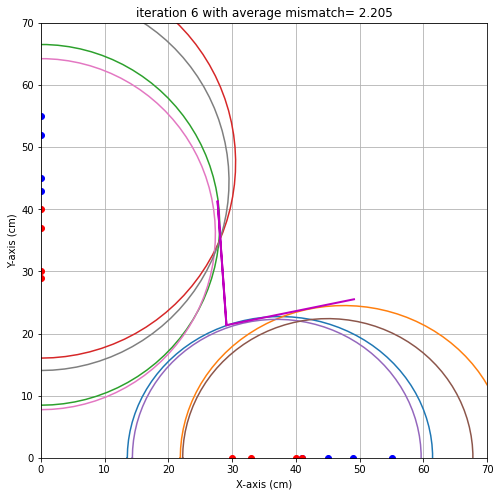

end iteration 6 with average mismatch= 2.205


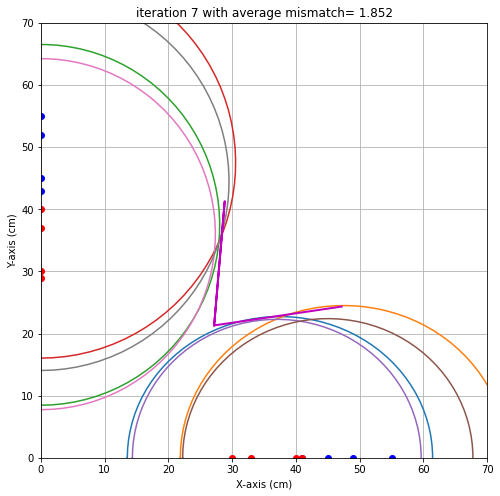

end iteration 7 with average mismatch= 1.852


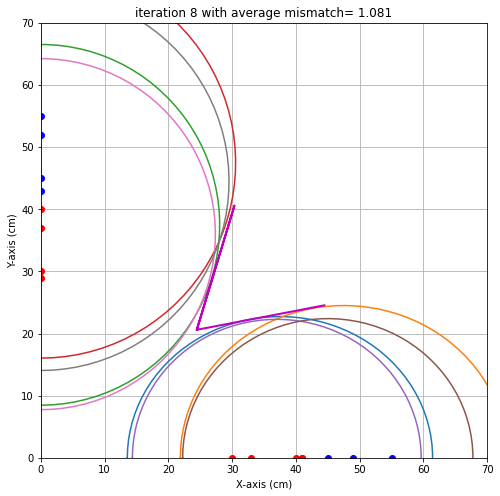

end iteration 8 with average mismatch= 1.081


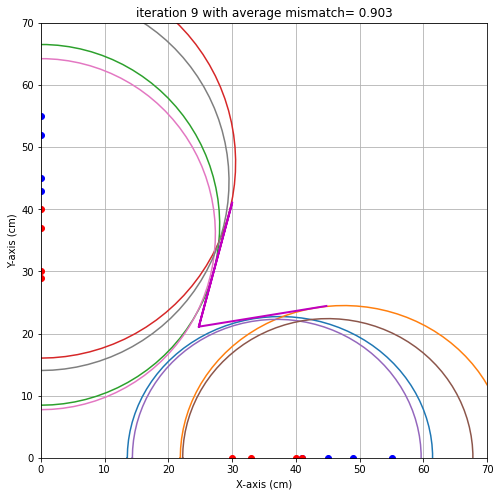

end iteration 9 with average mismatch= 0.903
end iteration 10 with average mismatch= 0.895
end iteration 11 with average mismatch= 0.889
end iteration 12 with average mismatch= 0.889
end iteration 13 with average mismatch= 0.889
end iteration 14 with average mismatch= 0.889
end iteration 15 with average mismatch= 0.827
end iteration 16 with average mismatch= 0.816
end iteration 17 with average mismatch= 0.800
end iteration 18 with average mismatch= 0.798
end iteration 19 with average mismatch= 0.797
end iteration 20 with average mismatch= 0.797
end iteration 21 with average mismatch= 0.796
end iteration 22 with average mismatch= 0.796
end iteration 23 with average mismatch= 0.796
end iteration 24 with average mismatch= 0.796
end iteration 25 with average mismatch= 0.796
end iteration 26 with average mismatch= 0.796
end iteration 27 with average mismatch= 0.796
end iteration 28 with average mismatch= 0.796
end iteration 29 with average mismatch= 0.796
Last iteration, also determine unce

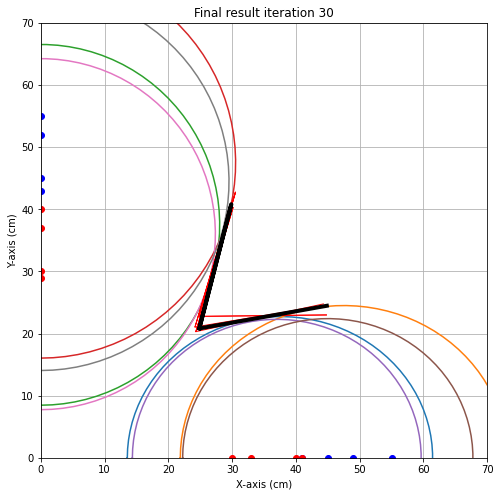

{'alpha': 10.346894137370446, 'alpha_eps': 9.67358087680819, 'beta': 14.089593775727403, 'beta_eps': 2.1973401269513086, 'x0': 24.85203732815079, 'x0_eps': 0.6739832877033649, 'y0': 20.82065431474449, 'y0_eps': 1.9397409443457185}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 32.8 cm met een standaardafwijking van 1.0 cm 
y0 target is : 33.0. Gevonden waarde: 36.7 cm met een standaardafwijking van 1.1 cm 
alpha target is : 9.0. Gevonden waarde: 8.4 graden met een standaardafwijking van 5.2 graad 
beta target is : -11.0. Gevonden waarde: -9.4 graden met een standaardafwijking van 4.1 graad 

locatie 2 
x0 target is : 23.0. Gevonden waarde: 24.9 cm met een standaardafwijking van 0.7 cm 
y0 target is : 21.0. Gevonden waarde: 20.8 cm met een standaardafwijking van 1.9 cm 
alpha target is : -3.0. Gevonden waarde: 10.3 graden met een standaardafwijking van 9.7 graad 
beta target is : 11.0. Gevonden waarde: 14.1 graden met een standaardafwijking van 2.2 graad 



In [15]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])
    x0=rough_location['x0']
    y0=rough_location['y0']
    alpha=rough_location['alpha']
    beta=rough_location['beta']
    
    

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_iteratie2.jpeg)


In [16]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  91.35
1  50   0  65   0  93.15
2  40   0  55   0  89.86
3  45   0  30   0  90.53
4   0  30   0  45  65.41
5   0  40   0  55  60.45
6   0  45   0  30  63.59


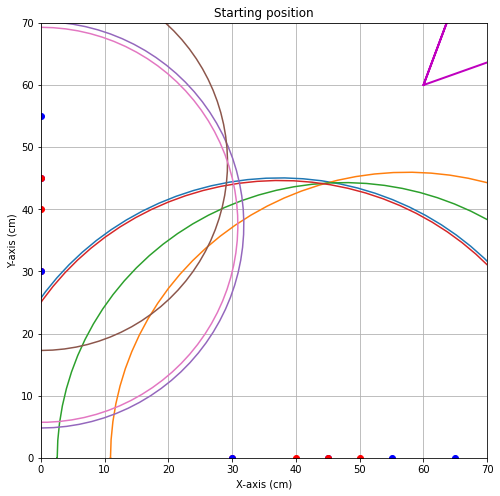


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=54.042


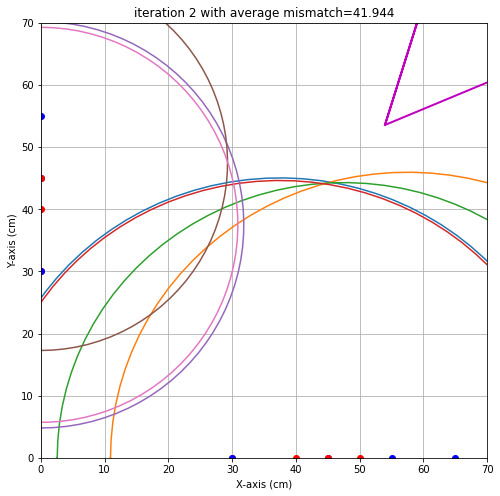

end iteration 2 with average mismatch=41.944


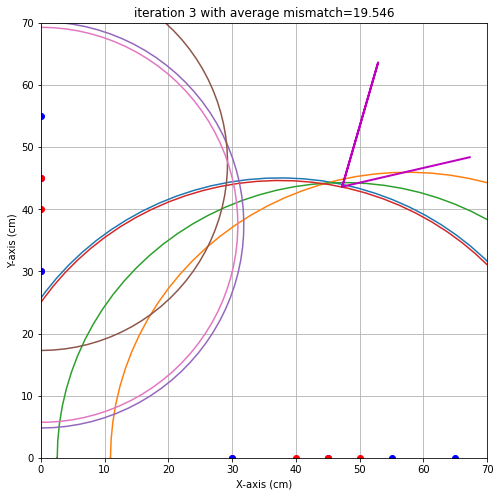

end iteration 3 with average mismatch=19.546


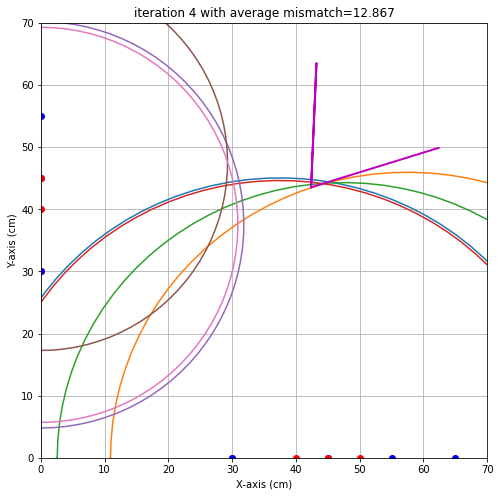

end iteration 4 with average mismatch=12.867


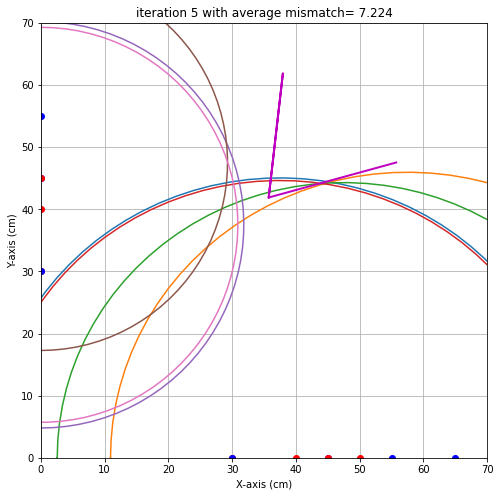

end iteration 5 with average mismatch= 7.224


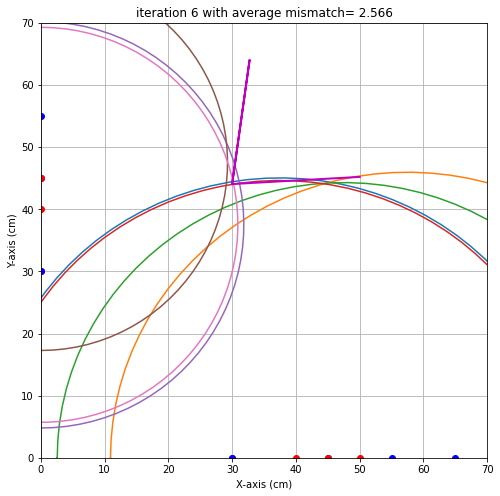

end iteration 6 with average mismatch= 2.566


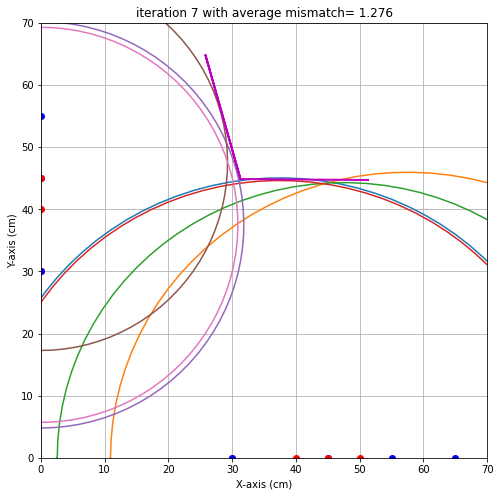

end iteration 7 with average mismatch= 1.276


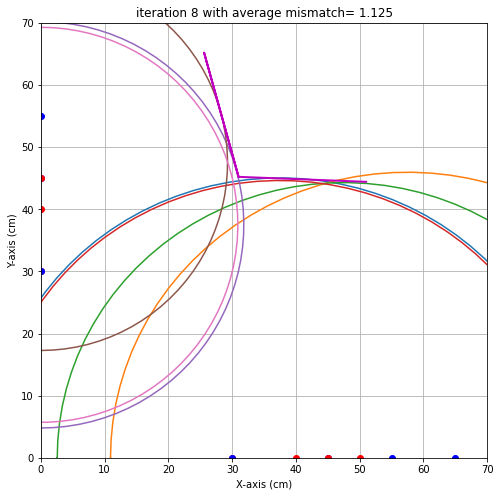

end iteration 8 with average mismatch= 1.125
end iteration 9 with average mismatch= 1.124
end iteration 10 with average mismatch= 1.124
end iteration 11 with average mismatch= 1.124
end iteration 12 with average mismatch= 1.124
end iteration 13 with average mismatch= 1.124
end iteration 14 with average mismatch= 1.108


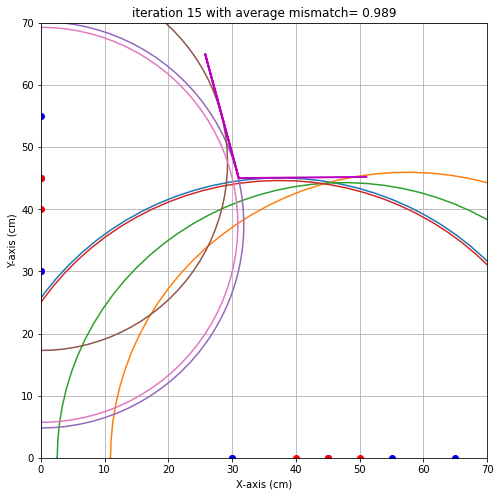

end iteration 15 with average mismatch= 0.989
end iteration 16 with average mismatch= 0.962
end iteration 17 with average mismatch= 0.956
end iteration 18 with average mismatch= 0.954
end iteration 19 with average mismatch= 0.953
end iteration 20 with average mismatch= 0.953
end iteration 21 with average mismatch= 0.953
end iteration 22 with average mismatch= 0.953
end iteration 23 with average mismatch= 0.953
end iteration 24 with average mismatch= 0.953
end iteration 25 with average mismatch= 0.953
end iteration 26 with average mismatch= 0.953
end iteration 27 with average mismatch= 0.953
end iteration 28 with average mismatch= 0.953
end iteration 29 with average mismatch= 0.953
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.953
###############################################################################
end of iteration  30
Best alpha=   0.56 with uncer

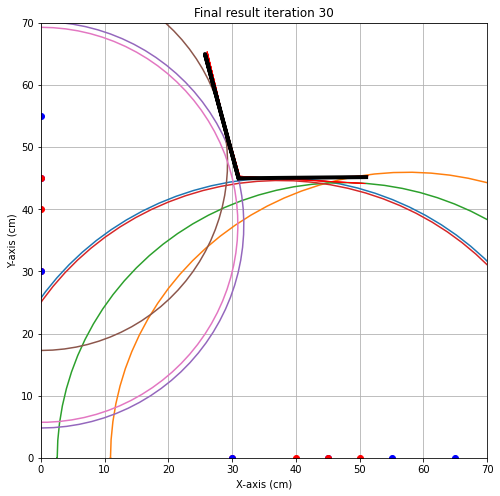

range s: x=[31.00777157 55.00664041], y=[44.98921827 68.19593312]
range r: x=[31.88147909 55.88600426], y=[27.41388494 54.88244779]
s pos: (39.00739451578029,0), (47.00701746255324,0), (0,52.724789887603784), (0,60.46036150226102)
r pos: (39.882987478395584,0), (47.884495869043675,0), (0,36.570072556692246), (0,45.72626017197247)


In [17]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':24,
                    'y0':29.5,
                    'alpha' : 10,
                    'beta' : 5},
           'locatie 2':{'x0':32,
                    'y0': 39.5,
                    'alpha' : 14,
                    'beta' : -15}
           }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,65.41],
    #[50,0,65,0,-],
    [40,0,55,0,69.32],
    [45,0,30,0,65.51],
    [0,30,0,45,51.15],
    [0,40,0,55,52.84],
    [0,50,0,65,58.06],
    [0,45,0,30,50.71]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,91.35],
    [50,0,65,0,93.15],
    [40,0,55,0,89.86],
    [45,0,30,0,90.53],
    [0,30,0,45,65.41],
    [0,40,0,55,60.45],
    #[0,50,0,65,-],
    [0,45,0,30,63.59]
    ])
      }


rough_location = imagingDEF.imagingDEF(data['locatie 2'])
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')                        

In [18]:
data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,65.41],
    #[50,0,65,0,-],
    [40,0,55,0,69.32],
    [45,0,30,0,65.51],
    [0,30,0,45,51.15],
    [0,40,0,55,52.84],
    [0,50,0,65,58.06],
    [0,45,0,30,50.71],
    [31,0,44,0,64.60],
    [39,0,53,0,68.5],
    [0,38,0,47,50.3],
    [0,46,0,55,51.7]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,45,0,91.35],
    [50,0,65,0,93.15],
    [40,0,55,0,89.86],
    #[45,0,30,0,90.53],
    [0,30,0,45,65.41],
    [0,40,0,55,60.45],
    #[0,50,0,65,-],
    [0,45,0,30,63.59],
    [39,0,49,0,87.55],
    [47,0,57,0,90.08],
    [0,52,0,36,63.15],
    [0,60,0,45,59.09]
    ])
      }

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr      R
0   30   0  45   0  65.41
1   40   0  55   0  69.32
2   45   0  30   0  65.51
3    0  30   0  45  51.15
4    0  40   0  55  52.84
5    0  50   0  65  58.06
6    0  45   0  30  50.71
7   31   0  44   0  64.60
8   39   0  53   0  68.50
9    0  38   0  47  50.30
10   0  46   0  55  51.70


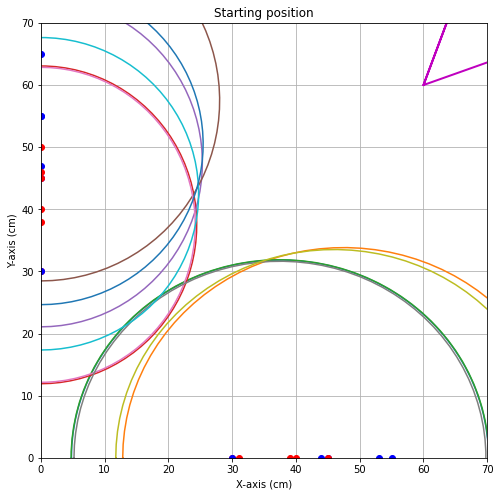


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.982


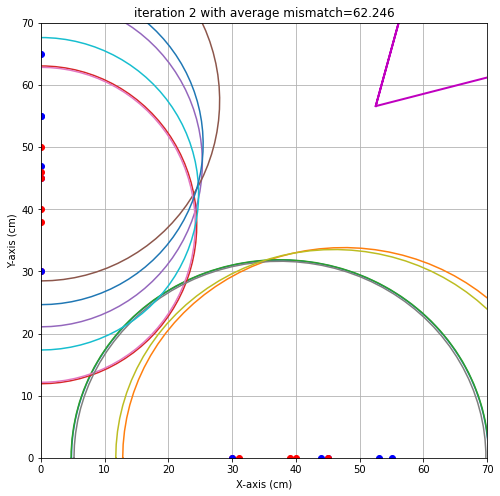

end iteration 2 with average mismatch=62.246


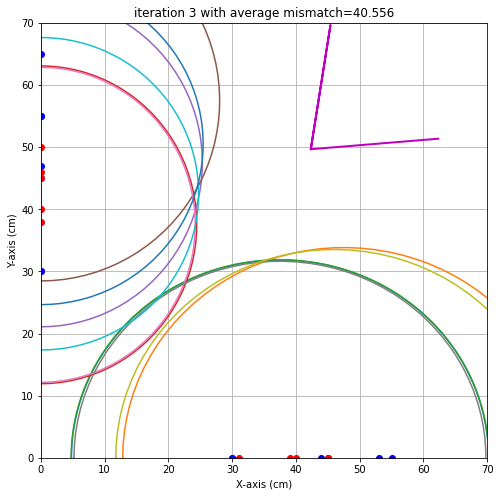

end iteration 3 with average mismatch=40.556


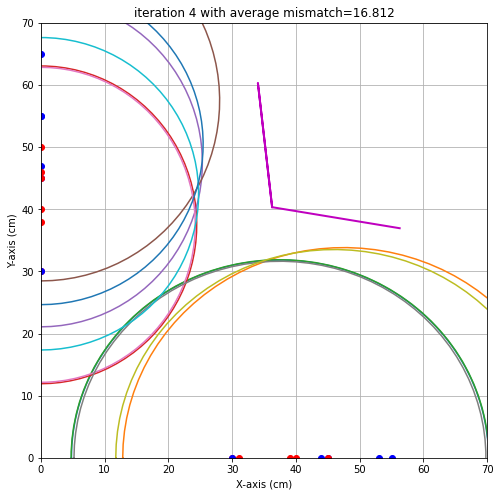

end iteration 4 with average mismatch=16.812


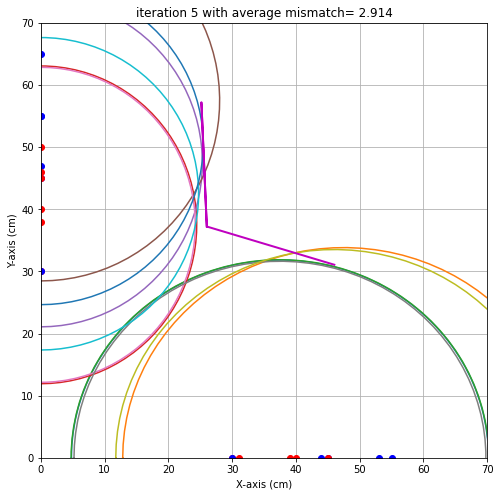

end iteration 5 with average mismatch= 2.914


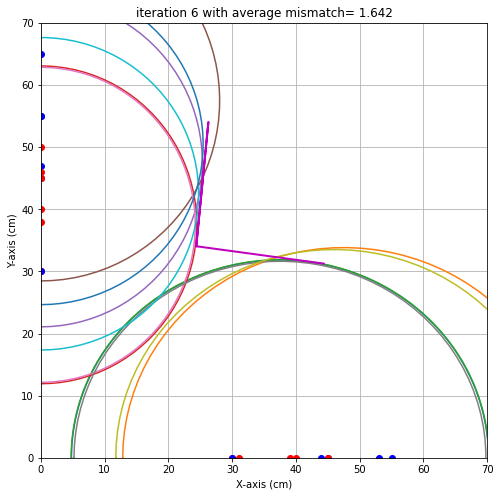

end iteration 6 with average mismatch= 1.642
end iteration 7 with average mismatch= 1.480
end iteration 8 with average mismatch= 1.479
end iteration 9 with average mismatch= 1.478
end iteration 10 with average mismatch= 1.478
end iteration 11 with average mismatch= 1.478
end iteration 12 with average mismatch= 1.478
end iteration 13 with average mismatch= 1.478
end iteration 14 with average mismatch= 1.478
end iteration 15 with average mismatch= 1.478
end iteration 16 with average mismatch= 1.478
end iteration 17 with average mismatch= 1.478
end iteration 18 with average mismatch= 1.478
end iteration 19 with average mismatch= 1.478
end iteration 20 with average mismatch= 1.478
end iteration 21 with average mismatch= 1.478
end iteration 22 with average mismatch= 1.478
end iteration 23 with average mismatch= 1.478
end iteration 24 with average mismatch= 1.478
end iteration 25 with average mismatch= 1.478
end iteration 26 with average mismatch= 1.478
end iteration 27 with average mismatch

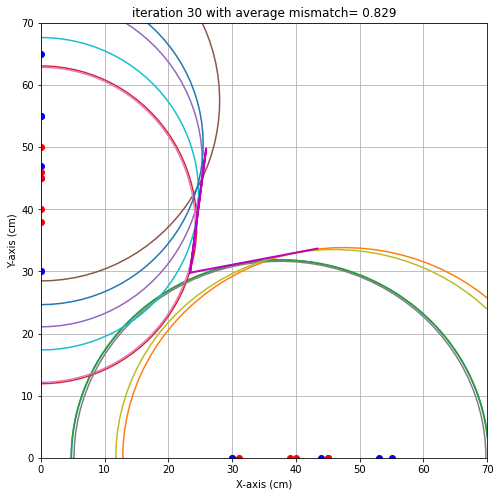

end iteration 30 with average mismatch= 0.829
###############################################################################
end of iteration  30
Best alpha=  10.99 with uncertainty=   6.08
Best beta =   7.21 with uncertainty=   1.47
Best x0   =  23.39 with uncertainty=   0.52
Best y0   =  29.79 with uncertainty=   0.98
###############################################################################


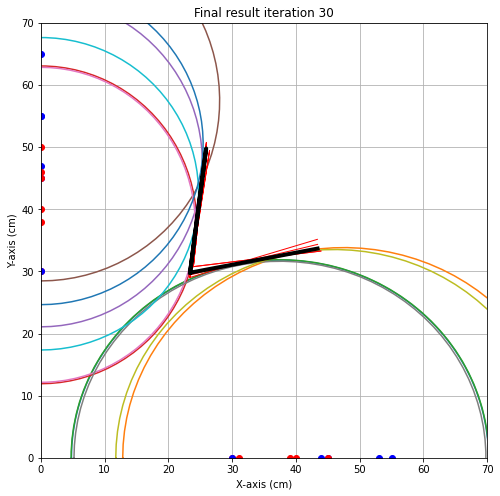

{'alpha': 10.990998107939262, 'alpha_eps': 6.0805122266835525, 'beta': 7.214340212803322, 'beta_eps': 1.4743966807486562, 'x0': 23.394042508956485, 'x0_eps': 0.5198420577071019, 'y0': 29.79217181942353, 'y0_eps': 0.975349262200659}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  50   0  65   0  93.15
1  40   0  55   0  89.86
2   0  30   0  45  65.41
3   0  40   0  55  60.45
4   0  45   0  30  63.59
5  39   0  49   0  87.55
6  47   0  57   0  90.08
7   0  52   0  36  63.15
8   0  60   0  45  59.09


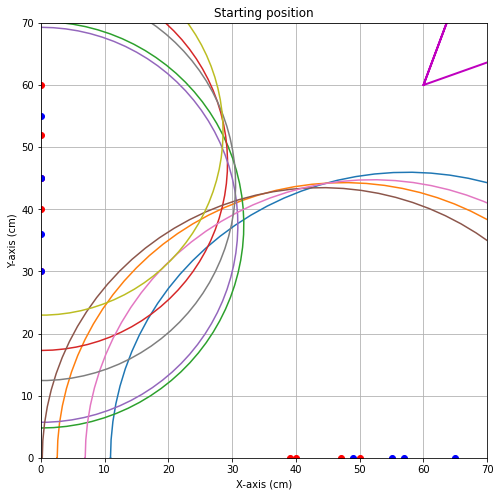


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=55.833


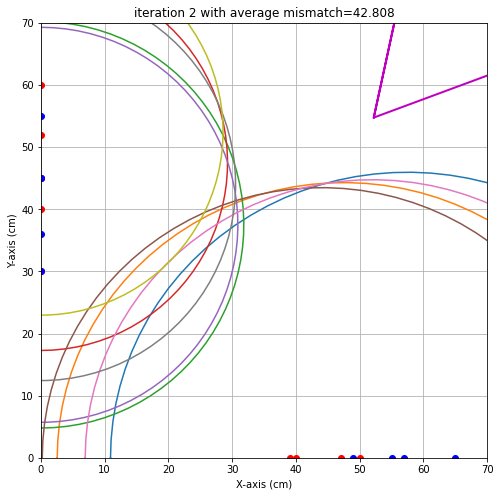

end iteration 2 with average mismatch=42.808


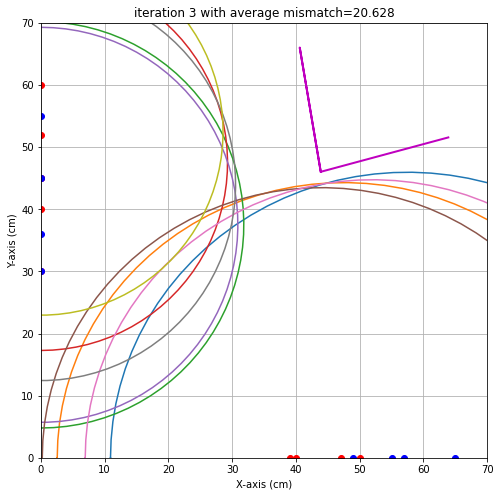

end iteration 3 with average mismatch=20.628


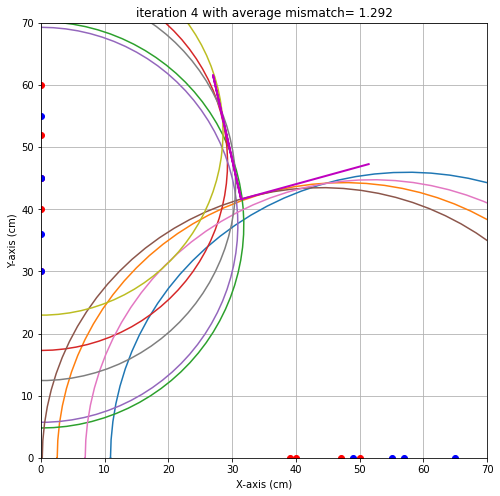

end iteration 4 with average mismatch= 1.292


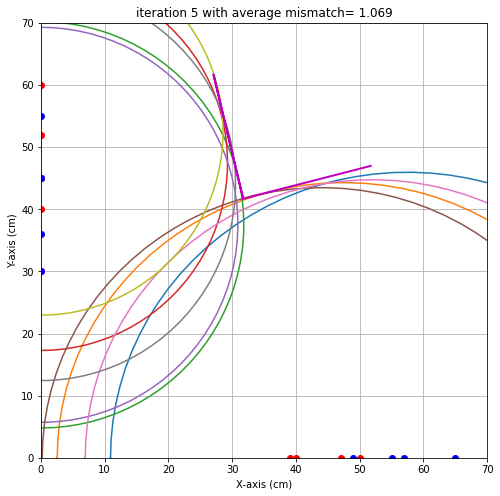

end iteration 5 with average mismatch= 1.069


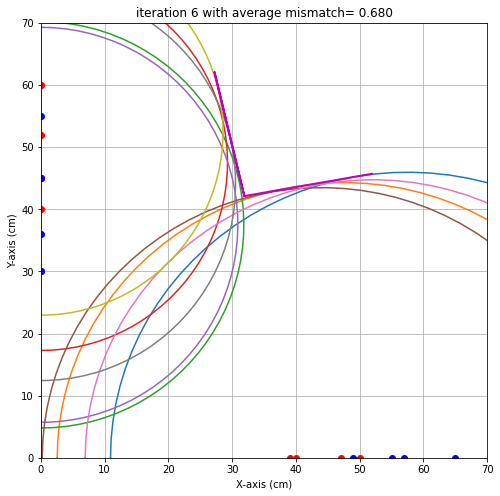

end iteration 6 with average mismatch= 0.680
end iteration 7 with average mismatch= 0.641
end iteration 8 with average mismatch= 0.636
end iteration 9 with average mismatch= 0.634
end iteration 10 with average mismatch= 0.634
end iteration 11 with average mismatch= 0.634
end iteration 12 with average mismatch= 0.634
end iteration 13 with average mismatch= 0.634
end iteration 14 with average mismatch= 0.634
end iteration 15 with average mismatch= 0.634
end iteration 16 with average mismatch= 0.634
end iteration 17 with average mismatch= 0.634
end iteration 18 with average mismatch= 0.634
end iteration 19 with average mismatch= 0.634
end iteration 20 with average mismatch= 0.634
end iteration 21 with average mismatch= 0.634
end iteration 22 with average mismatch= 0.634
end iteration 23 with average mismatch= 0.634
end iteration 24 with average mismatch= 0.634
end iteration 25 with average mismatch= 0.634
end iteration 26 with average mismatch= 0.634
end iteration 27 with average mismatch

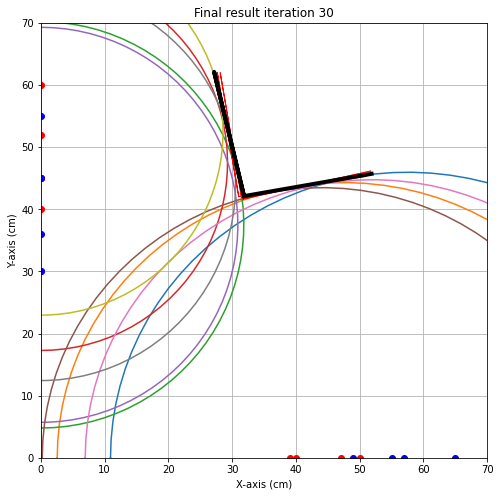

{'alpha': 10.162853134997288, 'alpha_eps': 2.5120696520732313, 'beta': -13.217068087836111, 'beta_eps': 3.7246457224918093, 'x0': 31.867390274191727, 'x0_eps': 0.8312191929774677, 'y0': 42.126410258231815, 'y0_eps': 0.4744646908758128}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 23.4 cm met een standaardafwijking van 0.5 cm 
y0 target is : 29.5. Gevonden waarde: 29.8 cm met een standaardafwijking van 1.0 cm 
alpha target is : 10.0. Gevonden waarde: 11.0 graden met een standaardafwijking van 6.1 graad 
beta target is : 5.0. Gevonden waarde: 7.2 graden met een standaardafwijking van 1.5 graad 

locatie 2 
x0 target is : 32.0. Gevonden waarde: 31.9 cm met een standaardafwijking van 0.8 cm 
y0 target is : 39.5. Gevonden waarde: 42.1 cm met een standaardafwijking van 0.5 cm 
alpha target is : 14.0. Gevonden waarde: 10.2 graden met een standaardafwijking van 2.5 graad 
beta target is : -15.0. Gevonden waarde: -13.2 graden met een standaardafwijking van 3.7 graad 



In [19]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])
    x0=rough_location['x0']
    y0=rough_location['y0']
    alpha=rough_location['alpha']
    beta=rough_location['beta']
    
    

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  41.92
1  45   0  30   0  42.32
2   0  30   0  45  49.49
3   0  40   0  55  54.18
4   0  50   0  65  79.89
5   0  45   0  30  48.79


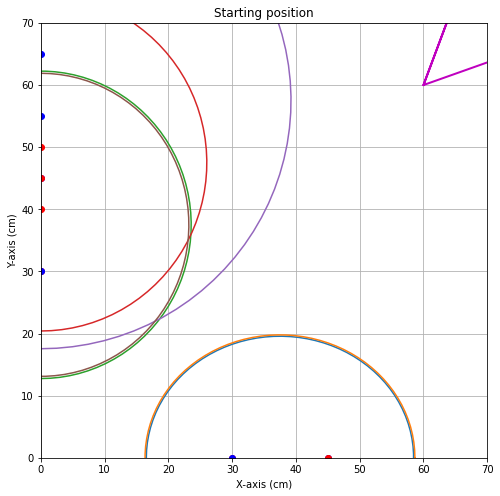


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.352


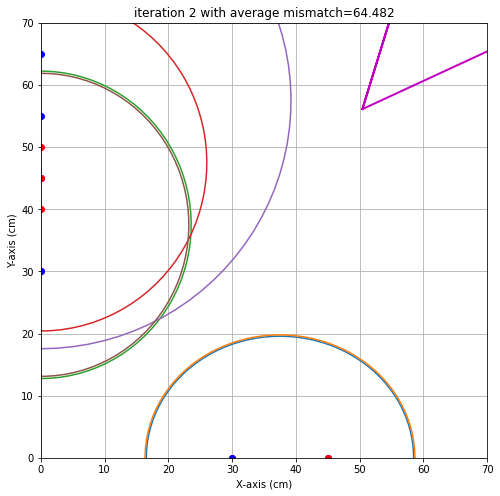

end iteration 2 with average mismatch=64.482


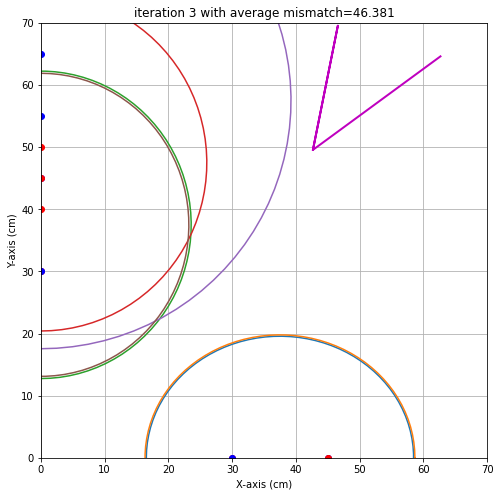

end iteration 3 with average mismatch=46.381


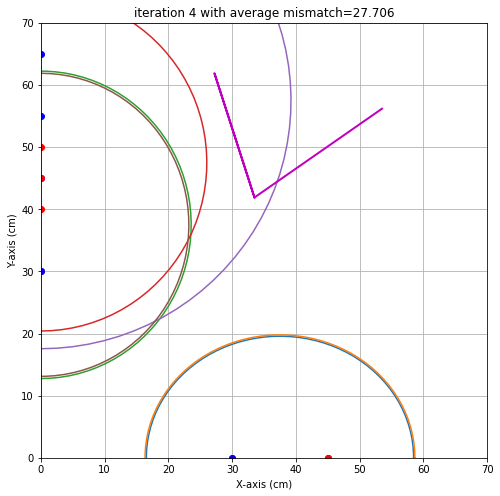

end iteration 4 with average mismatch=27.706


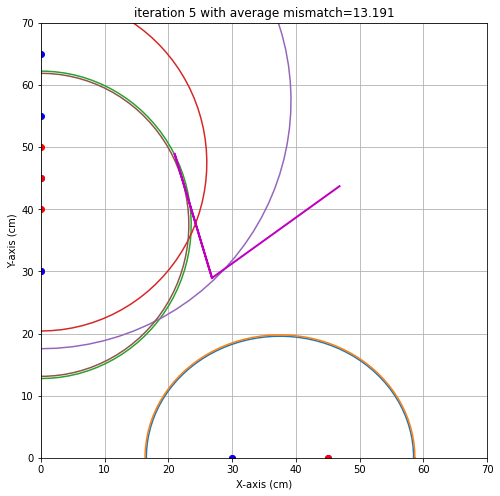

end iteration 5 with average mismatch=13.191
end iteration 6 with average mismatch=11.988


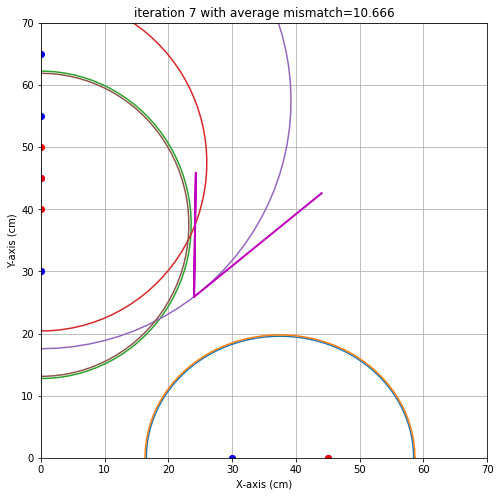

end iteration 7 with average mismatch=10.666


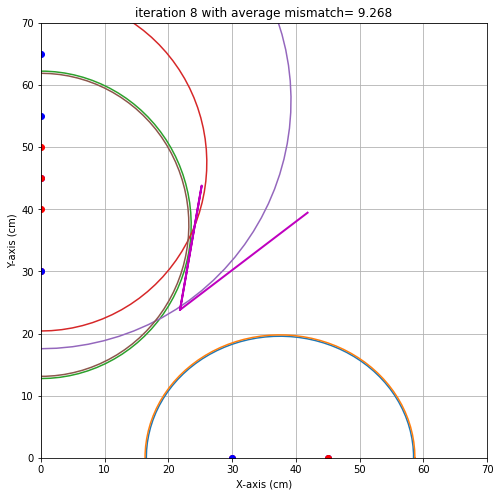

end iteration 8 with average mismatch= 9.268


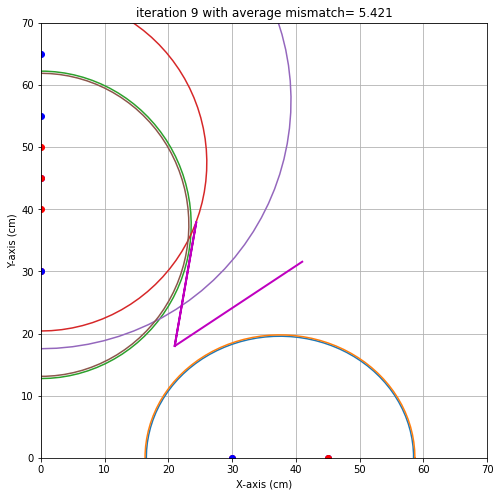

end iteration 9 with average mismatch= 5.421


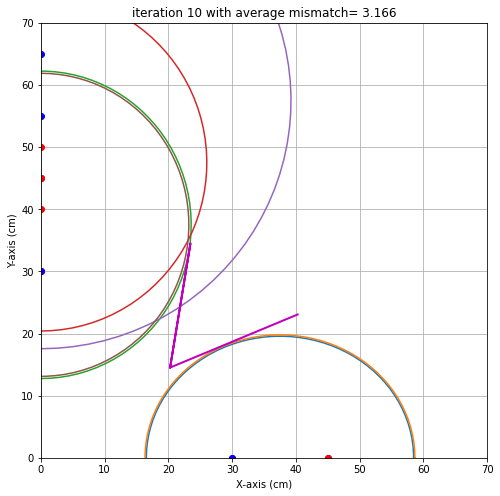

end iteration 10 with average mismatch= 3.166
end iteration 11 with average mismatch= 3.126
end iteration 12 with average mismatch= 3.088
end iteration 13 with average mismatch= 3.063
end iteration 14 with average mismatch= 3.063
end iteration 15 with average mismatch= 3.063
end iteration 16 with average mismatch= 3.063
end iteration 17 with average mismatch= 3.063
end iteration 18 with average mismatch= 3.040
end iteration 19 with average mismatch= 3.040
end iteration 20 with average mismatch= 3.040
end iteration 21 with average mismatch= 3.040
end iteration 22 with average mismatch= 3.040
end iteration 23 with average mismatch= 3.040
end iteration 24 with average mismatch= 3.040
end iteration 25 with average mismatch= 3.040
end iteration 26 with average mismatch= 3.040
end iteration 27 with average mismatch= 3.040
end iteration 28 with average mismatch= 3.040
end iteration 29 with average mismatch= 3.040
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

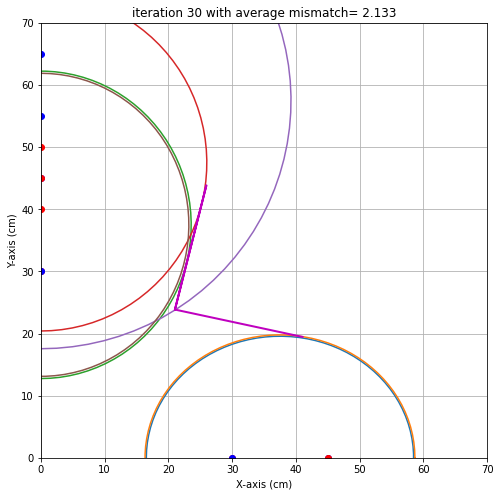

end iteration 30 with average mismatch= 2.133
###############################################################################
end of iteration  30
Best alpha= -12.41 with uncertainty=  14.84
Best beta =  13.85 with uncertainty=  11.68
Best x0   =  21.03 with uncertainty=   3.35
Best y0   =  23.86 with uncertainty=   4.92
###############################################################################


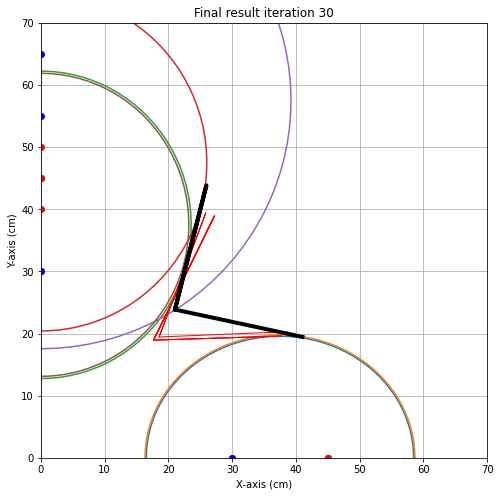

range s: x=[21.03015733 44.46943707], y=[23.85947096 47.16122921]
range r: x=[ 9.99592988 36.38112159], y=[34.90484382 61.92326201]
s pos: (28.843250578651666,0), (36.65634382444361,0), (0,31.62672371211475), (0,39.393976459907186)
r pos: (18.790993781315734,0), (27.586057683639247,0), (0,43.910983218892746), (0,52.91712261629846)


In [20]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  20,
                    'y0':  22,
                    'alpha' :  -12,
                    'beta' :  14
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [30,0,45,0,41.92],
                    #[40,0,55,0,-],
                    #[50,0,65,0,-],
                    [45,0,30,0,42.32],
                    [0,30,0,45,49.49],
                    [0,40,0,55,54.18],
                    [0,50,0,65,79.89],
                    [0,45,0,30,48.79]
                    ])
                }


rough_location = imagingDEF.imagingDEF(dataFinalCheck['test locatie'])
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')                        


In [21]:
dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [30,0,45,0,41.92],
                    #[40,0,55,0,-],
                    #[50,0,65,0,-],
                    [45,0,30,0,42.32],
                    [0,30,0,45,49.49],
                    [0,40,0,55,54.18],
                    #[0,50,0,65,79.89],
                    [0,45,0,30,48.79],
                    [28,0,18,0,43.91],
                    [36,0,26,0,41.18],
                    [0,29,0,41,47.88],
                    [0,37,0,50,51.03]
                    ])
                }

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  41.92
1  45   0  30   0  42.32
2   0  30   0  45  49.49
3   0  40   0  55  54.18
4   0  45   0  30  48.79
5  28   0  18   0  43.91
6  36   0  26   0  41.18
7   0  29   0  41  47.88
8   0  37   0  50  51.03


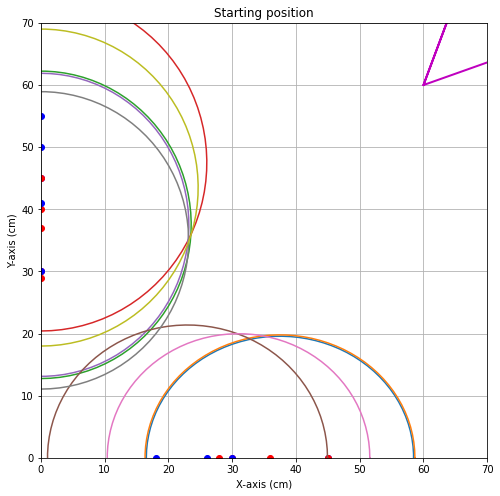


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=89.579


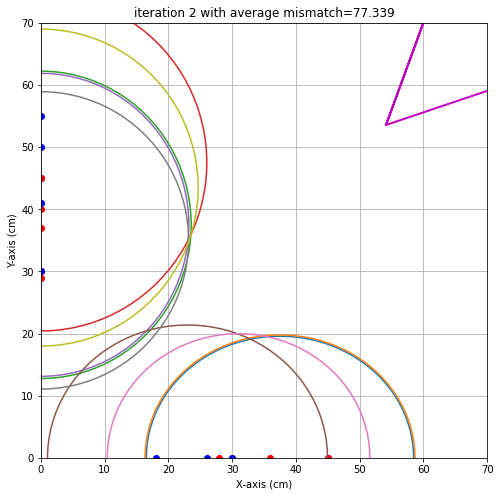

end iteration 2 with average mismatch=77.339


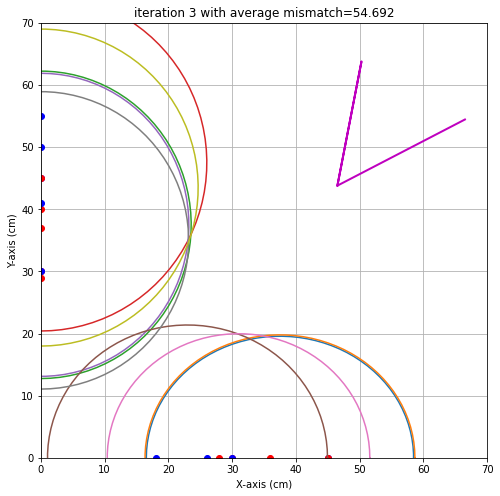

end iteration 3 with average mismatch=54.692


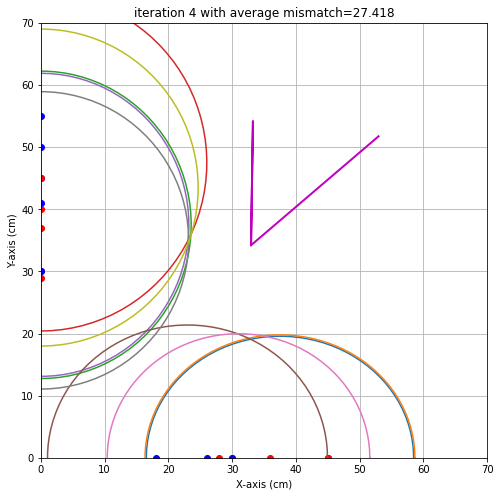

end iteration 4 with average mismatch=27.418


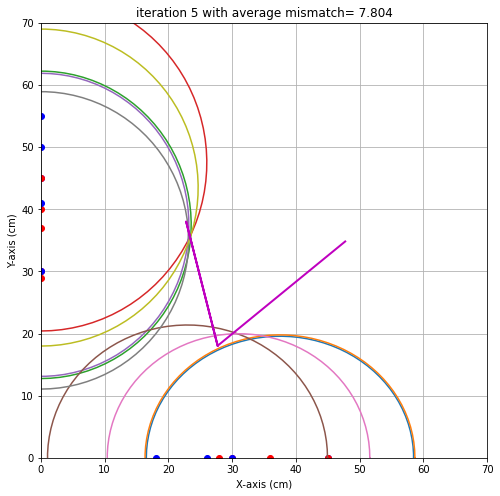

end iteration 5 with average mismatch= 7.804


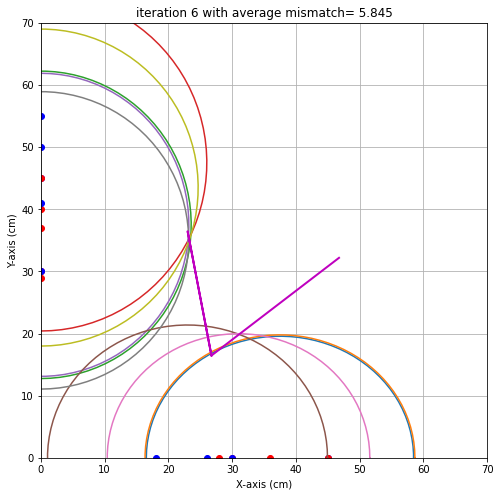

end iteration 6 with average mismatch= 5.845
end iteration 7 with average mismatch= 5.754
end iteration 8 with average mismatch= 5.474
end iteration 9 with average mismatch= 5.340


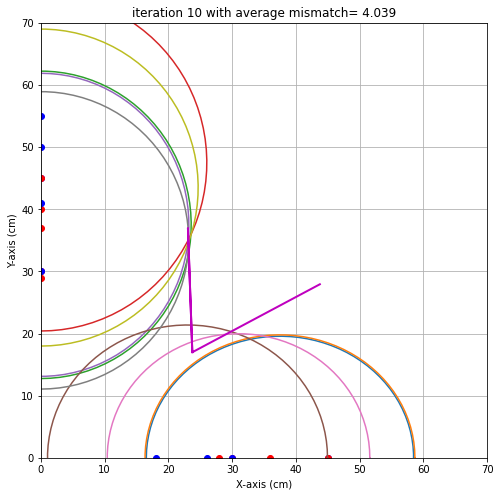

end iteration 10 with average mismatch= 4.039


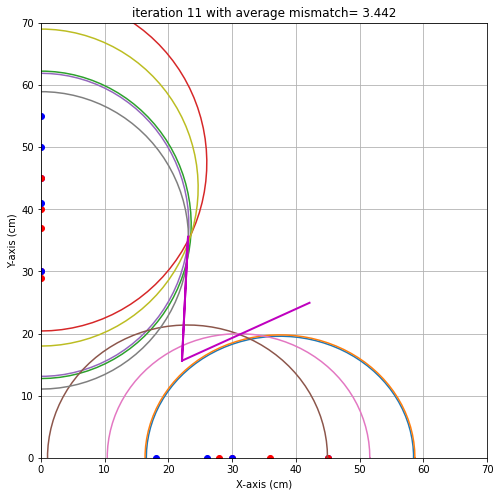

end iteration 11 with average mismatch= 3.442
end iteration 12 with average mismatch= 3.387
end iteration 13 with average mismatch= 3.387
end iteration 14 with average mismatch= 3.387


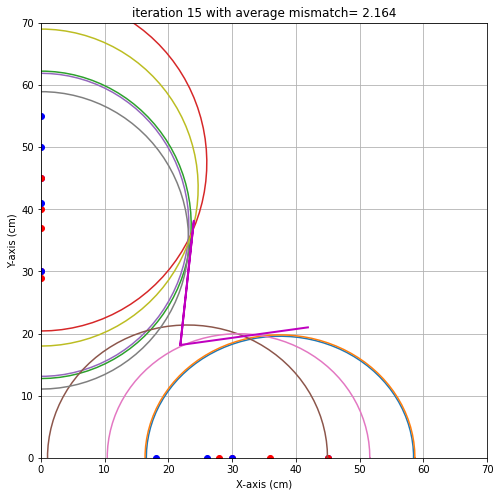

end iteration 15 with average mismatch= 2.164


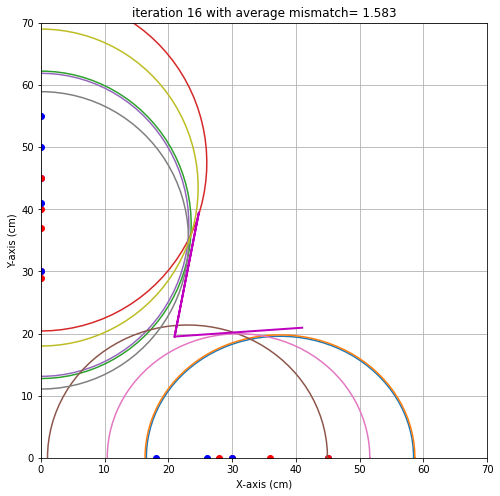

end iteration 16 with average mismatch= 1.583


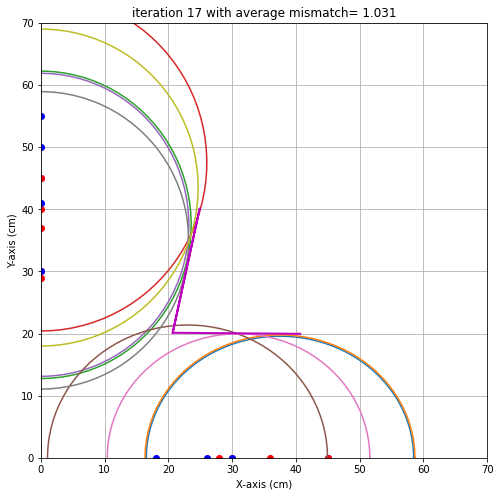

end iteration 17 with average mismatch= 1.031


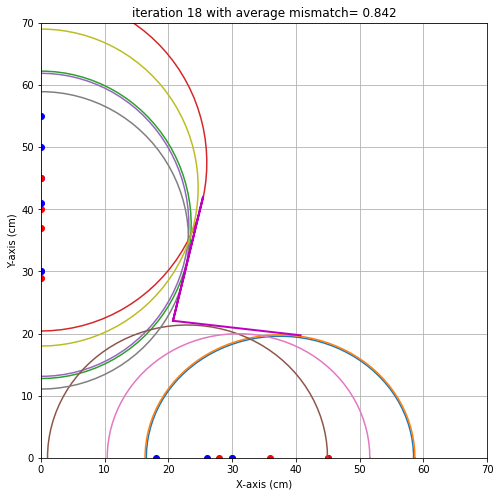

end iteration 18 with average mismatch= 0.842


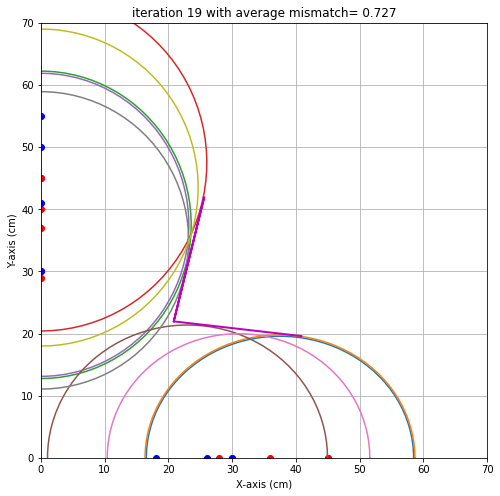

end iteration 19 with average mismatch= 0.727
end iteration 20 with average mismatch= 0.711
end iteration 21 with average mismatch= 0.654
end iteration 22 with average mismatch= 0.649
end iteration 23 with average mismatch= 0.630
end iteration 24 with average mismatch= 0.624
end iteration 25 with average mismatch= 0.624
end iteration 26 with average mismatch= 0.624
end iteration 27 with average mismatch= 0.624
end iteration 28 with average mismatch= 0.624
end iteration 29 with average mismatch= 0.624
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.624
###############################################################################
end of iteration  30
Best alpha=  -6.80 with uncertainty=   2.12
Best beta =  13.40 with uncertainty=   2.40
Best x0   =  20.70 with uncertainty=   0.34
Best y0   =  21.80 with uncertainty=   0.46
##############################################################

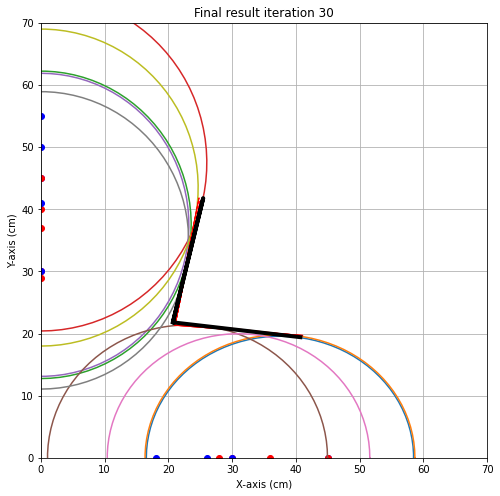

{'alpha': -6.795842805232092, 'alpha_eps': 2.1185701505845733, 'beta': 13.402932383994399, 'beta_eps': 2.4028155464100625, 'x0': 20.701419393134444, 'x0_eps': 0.3427350181165245, 'y0': 21.800946852633682, 'y0_eps': 0.46470422911058407}
test locatie 
x0 target is : 20.0. Gevonden waarde: 20.7 cm met een standaardafwijking van 0.3 cm 
y0 target is : 22.0. Gevonden waarde: 21.8 cm met een standaardafwijking van 0.5 cm 
alpha target is : -12.0. Gevonden waarde: -6.8 graden met een standaardafwijking van 2.1 graad 
beta target is : 14.0. Gevonden waarde: 13.4 graden met een standaardafwijking van 2.4 graad 



In [22]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](algoritme_moene.jpg "moene")
Dit was het eerste agoritme wat Moene had geschreven, eerst breed kijken om daarna met een algoritme de volgende meetpunten te bepalen.
Figuur: ![Alt](algoritme_erik.jpg "erik")
Dit is het eerste algoritme wat Erik heeft geschreven, Eerst breed kijken om vervolgens via een voorbedachte volgorde de specfiekere metingen uit te voeren.
Figuur: ![Alt](algoritme_raphaelle.jpg "raphaelle")
Dit was het eerste algoritme van Raphaelle, Hierbij meet je van 2 kanten waardoor de hoeken bepaald zouden kunnen worden, echter werkte dit niet heel goed en zijn we dus niet verder gegaan met dit algoritme.
Figuur: ![Alt](algoritme_iteratie.jpg "iteratie 1")
Bij deze itteratie hebben we de goede aspecten van de eerste algoritmes van Erik en Moene gebruikt, Het eerst een paar metingen algemeen om daarna te specificeren leek goed te werken, Het algoritme in het eerste idee van Moene om de specefieke meetpunten te kiezen werkt goed, deze gebruiken we dus verder.
Figuur: ![Alt](algoritme_iteratie2.jpeg "iteratie 2")
Bij deze itteratie hebben we erbij gezet dat er bij het eerste onderdeel ook een meting wordt gedaan waarbij de source en receiver andersom staan, hiermee wordt ook nog rekening gehouden met een negatieve hoek.

Figuur: ![Alt](algoritme_final.jpg "final")
Bij de laatste itteratie hebben we ook nog toegevoegd dat groote afwijkende resultaten werwijderd worden, dit zorgt ervoor dat grote meetfouten worden gecompenseerd en geen invloed hebben op de daadwerkelijke uitkomst.